In [1]:
!pwd

/mnt/c/Users/vasil/Desktop/lncAPNet/notebooks/Post-hoc_Analysis


In [2]:
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

In [3]:
####################################################
## Clinical Covariates ##
####################################################

/tmp/ipykernel_3501/99539954.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clinical_subset['IGHV'] = clinical_subset['IGHV'].map({'U': 0, 'M': 1})


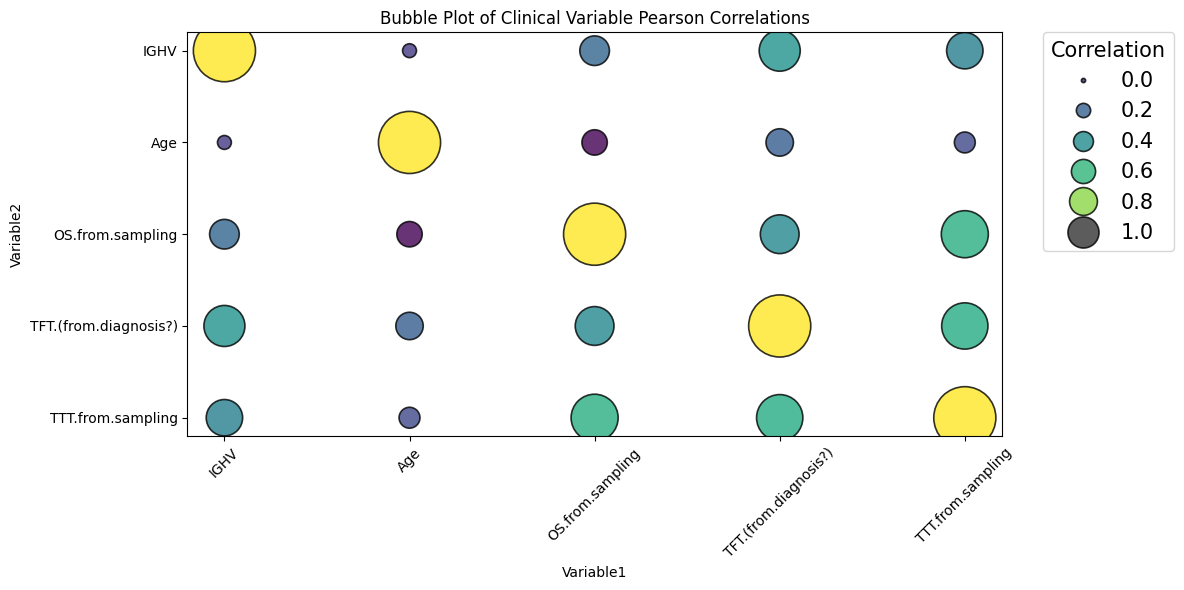

In [4]:
## BCMO
# Load data
clinical = pd.read_csv("../../data/BCMO/clinical_info.csv")

# Select columns of interest
cols_of_interest = ["IGHV", "Age", "OS.from.sampling", "TFT.(from.diagnosis?)", "TTT.from.sampling"]
clinical_subset = clinical[cols_of_interest]

# Encode categorical columns to numeric
clinical_subset['IGHV'] = clinical_subset['IGHV'].map({'U': 0, 'M': 1})

# Compute correlation matrix
corr_matrix = clinical_subset.corr()

# Melt for plotting
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['Variable1', 'Variable2', 'Correlation']

# Bubble plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=corr_long,
    x='Variable1',
    y='Variable2',
    size=corr_long['Correlation'].abs(),  # size by magnitude
    hue='Correlation',                    # color by sign
    sizes=(100, 2000),
    palette='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Rotate labels
plt.xticks(rotation=45)
plt.title("Bubble Plot of Clinical Variable Pearson Correlations")

# Adjust legend
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.,
    title='Correlation',
    fontsize=15,
    title_fontsize=15,
    markerscale=0.5
)

# Ensure labels are not cut off
plt.tight_layout()

# Save figure with extra space for labels
plt.savefig("../../figures/Clinical_Covariates.png", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3501/864898032.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clinical_subset['IGHV'] = clinical_subset['IGHV'].map({'U': 0, 'M': 1})
/tmp/ipykernel_3501/864898032.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clinical_subset['donor_vital_status'] = clinical_subset['donor_vital_status'].map({'alive': 0, 'deceased': 1})


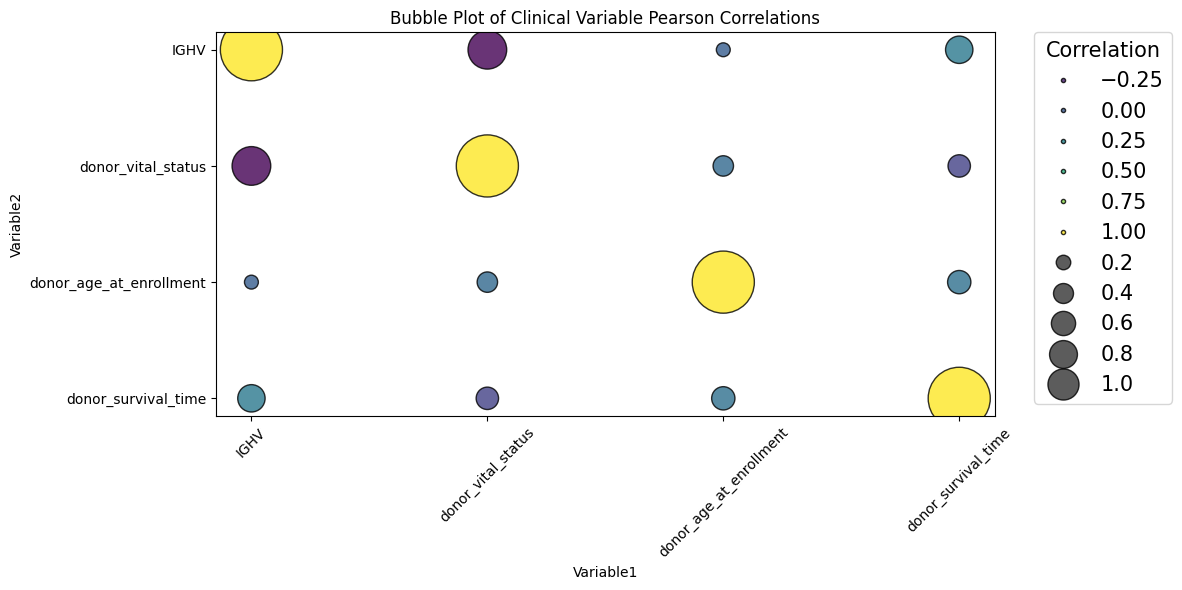

In [5]:
## ICGC
# Load data
clinical = pd.read_csv("../../data/ICGC/clinical_info.csv")

# Select columns of interest
cols_of_interest = ["IGHV", "donor_vital_status", "donor_age_at_enrollment", "donor_survival_time"]
clinical_subset = clinical[cols_of_interest]

# Encode categorical columns to numeric
clinical_subset['IGHV'] = clinical_subset['IGHV'].map({'U': 0, 'M': 1})
clinical_subset['donor_vital_status'] = clinical_subset['donor_vital_status'].map({'alive': 0, 'deceased': 1})

# Compute correlation matrix
corr_matrix = clinical_subset.corr()

# Melt for plotting
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['Variable1', 'Variable2', 'Correlation']

# Bubble plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=corr_long,
    x='Variable1',
    y='Variable2',
    size=corr_long['Correlation'].abs(),  # size by magnitude
    hue='Correlation',                    # color by sign
    sizes=(100, 2000),
    palette='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Rotate labels
plt.xticks(rotation=45)
plt.title("Bubble Plot of Clinical Variable Pearson Correlations")

# Adjust legend
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.,
    title='Correlation',
    fontsize=15,
    title_fontsize=15,
    markerscale=0.5
)

# Ensure labels are not cut off
plt.tight_layout()

# Save figure with extra space for labels
plt.savefig("../../figures/Clinical_Covariates_ICGC.png", dpi=300, bbox_inches='tight')
plt.show()


In [6]:
####################################################
## Kaplan Meiers ##
####################################################

In [22]:
def kaplan_meier_plots(
    clinical_file,
    expr_file,
    genes,
    output_file,
    split_method="median",
    fig_title=None,
    time_col="OS.from.sampling"
):
    """
    Generate Kaplan-Meier survival plots for a list of genes.

    Parameters:
    - clinical_file: path to clinical CSV (must have Sample_ID and Status)
    - expr_file: path to expression/activity CSV (genes x samples)
    - genes: list of gene names to analyze
    - output_file: path to save the figure
    - split_method: "median" or "quartile"
    - fig_title: string for the figure-wide title (optional)
    - time_col: name of the time column in clinical data
    """
    # 1. Load clinical data
    clinical = pd.read_csv(clinical_file)
    clinical = clinical.rename(columns={"died": "Status"})
    
    # 2. Load expression/activity matrix
    expr = pd.read_csv(expr_file, index_col=0)
    
    # 3. Determine subplot grid size dynamically
    n_genes = len(genes)
    n_cols = 2
    n_rows = math.ceil(n_genes / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9 * n_rows))
    axes = axes.flatten()
    
    # 4. Figure-wide title
    if fig_title is None:
        title_map = {
            "median": "Survival Analysis of BCMO for ALL Genes -- ACTIVITY",
            "quartile": "Survival Analysis of BCMO for Quartile Genes (Activity)"
        }
        fig_title = title_map.get(split_method, "Survival Analysis")
    fig.suptitle(fig_title, fontsize=30, y=1.02)
    
    # 5. Loop through genes
    for i, gene in enumerate(genes):
        ax = axes[i]
        
        if gene not in expr.index:
            ax.text(0.5, 0.5, f"{gene} not found", ha='center', va='center', fontsize=14)
            ax.axis('off')
            continue
        
        # Extract gene activity
        gene_activity = expr.loc[gene].rename("Activity")
        
        # Merge with clinical data
        df = clinical.merge(gene_activity, left_on="Sample_ID", right_index=True)
        
        # Define High/Low groups
        if split_method == "median":
            df[f"{gene}_group"] = (df["Activity"] > df["Activity"].median()).map({True: "High", False: "Low"})
            df_to_use = df
        elif split_method == "quartile":
            q_low = df["Activity"].quantile(0.25)
            q_high = df["Activity"].quantile(0.75)
            df_to_use = df[(df["Activity"] <= q_low) | (df["Activity"] >= q_high)].copy()
            df_to_use[f"{gene}_group"] = df_to_use["Activity"].apply(lambda x: "High" if x >= q_high else "Low")
        else:
            raise ValueError("split_method must be 'median' or 'quartile'")
        
        # Kaplan–Meier plot
        kmf = KaplanMeierFitter()
        for group, grouped_df in df_to_use.groupby(f"{gene}_group"):
            kmf.fit(grouped_df[time_col], grouped_df["Status"], label=group)
            kmf.plot_survival_function(ax=ax, ci_show=True)
        
        # Log-rank test
        high = df_to_use[df_to_use[f"{gene}_group"] == "High"]
        low = df_to_use[df_to_use[f"{gene}_group"] == "Low"]
        results = logrank_test(
            high[time_col], low[time_col],
            event_observed_A=high["Status"], event_observed_B=low["Status"]
        )
        pval = results.p_value

        # Format p-value
        if pval >= 0.005:
            pval_str = f"{pval:.4f}"
        else:
            pval_str = f"{pval:.1e}".replace("e-0", "e-").replace("e", "×10")

        # Set subplot title and labels
        ax.set_title(f"{gene} (p = {pval_str})", fontsize=25)
        ax.set_xlabel(f"Time from Sampling ({time_col})", fontsize=16)
        ax.set_ylabel("Overall Survival Probability", fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        ax.legend(fontsize=14)
    
    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()


In [8]:
# For Survival STATUS (OS)

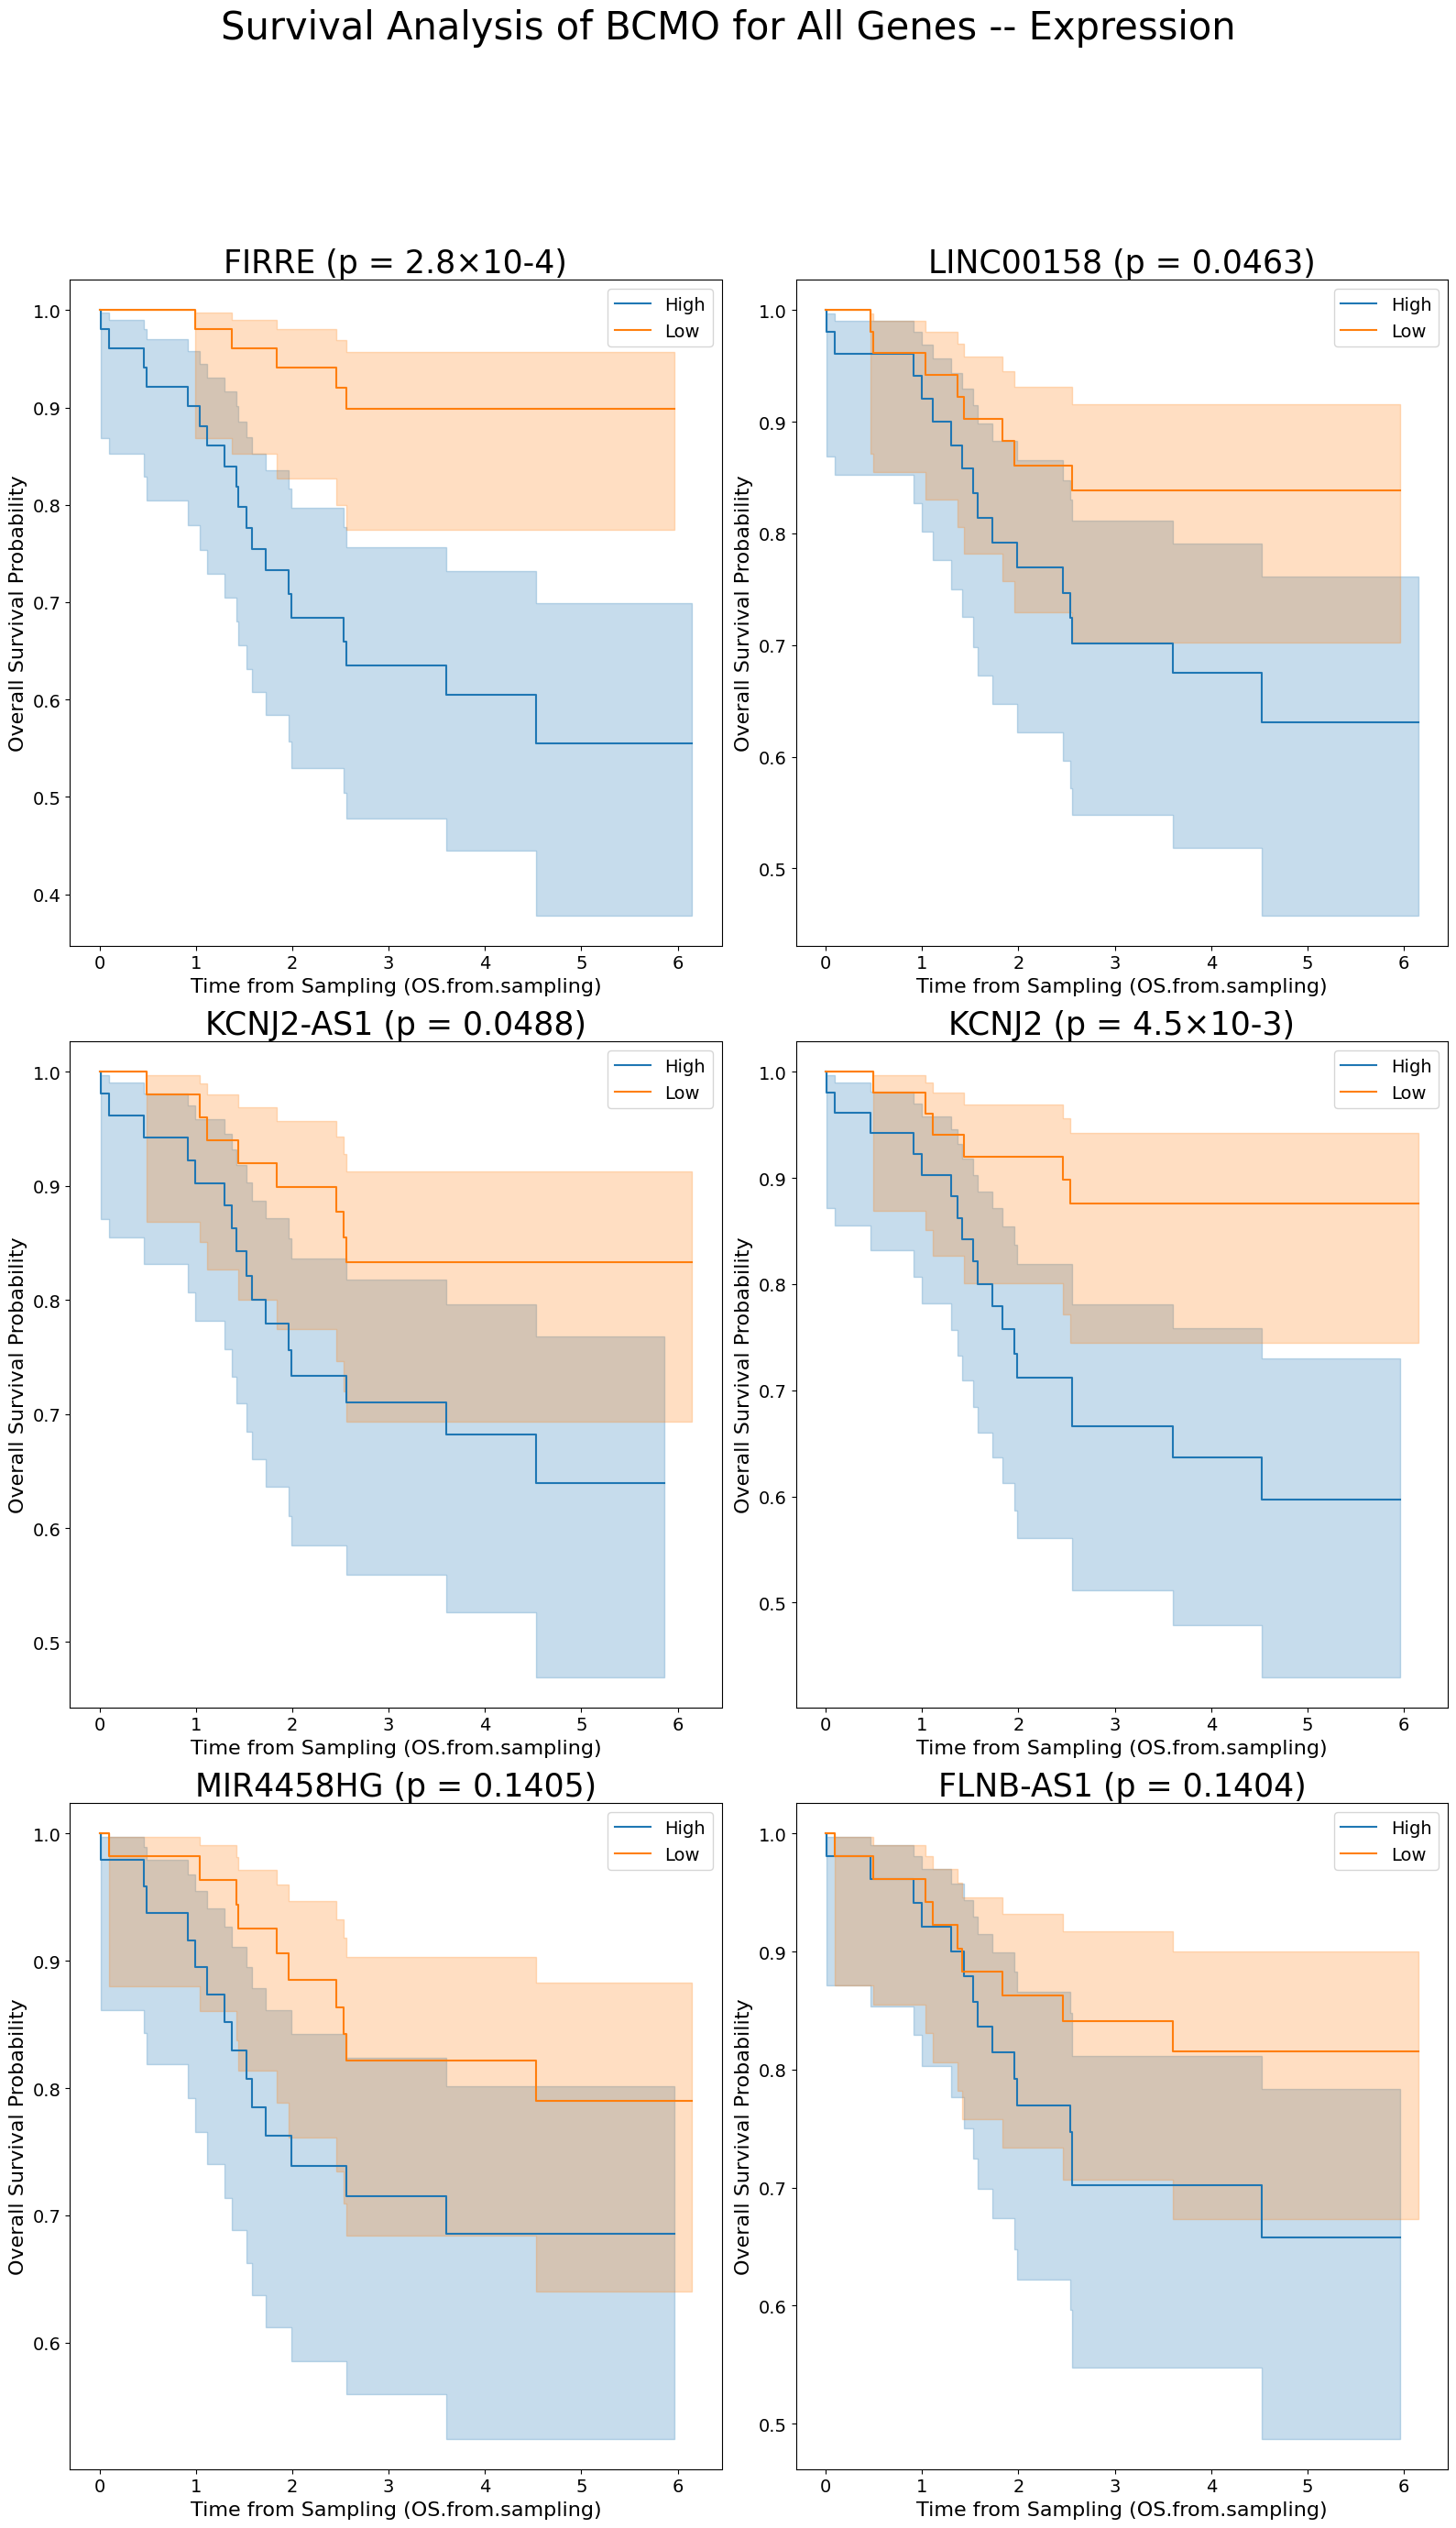

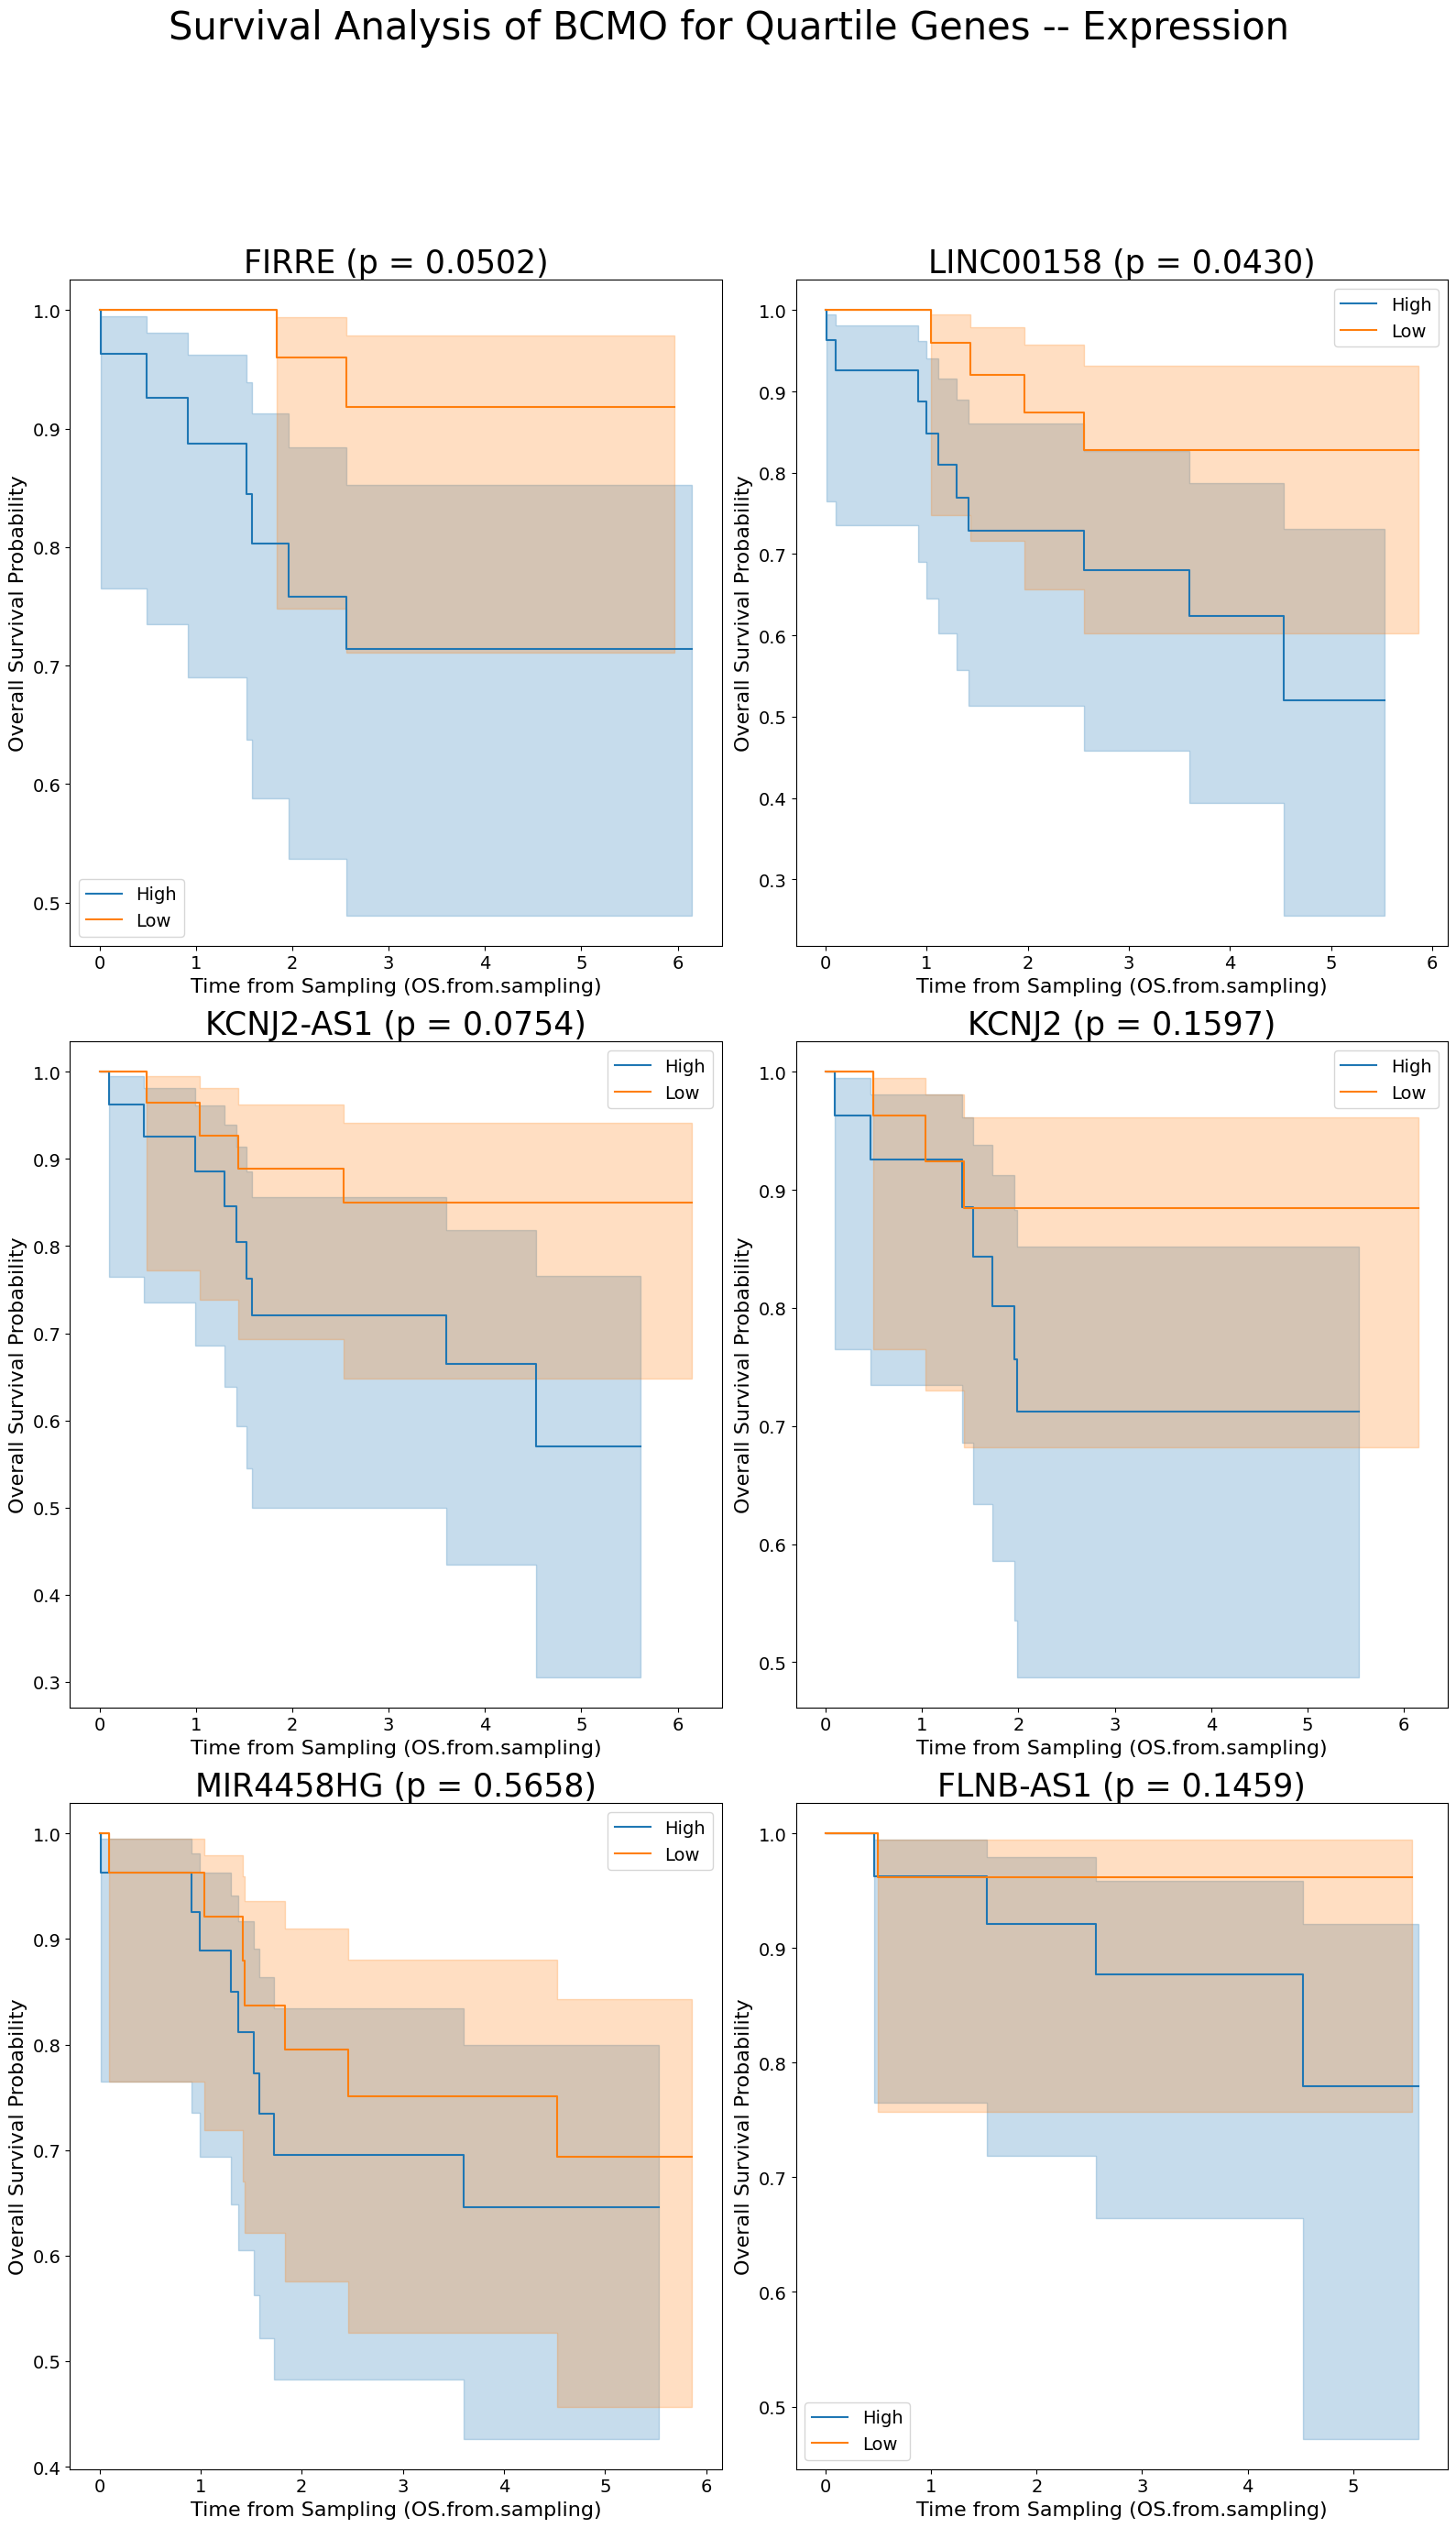

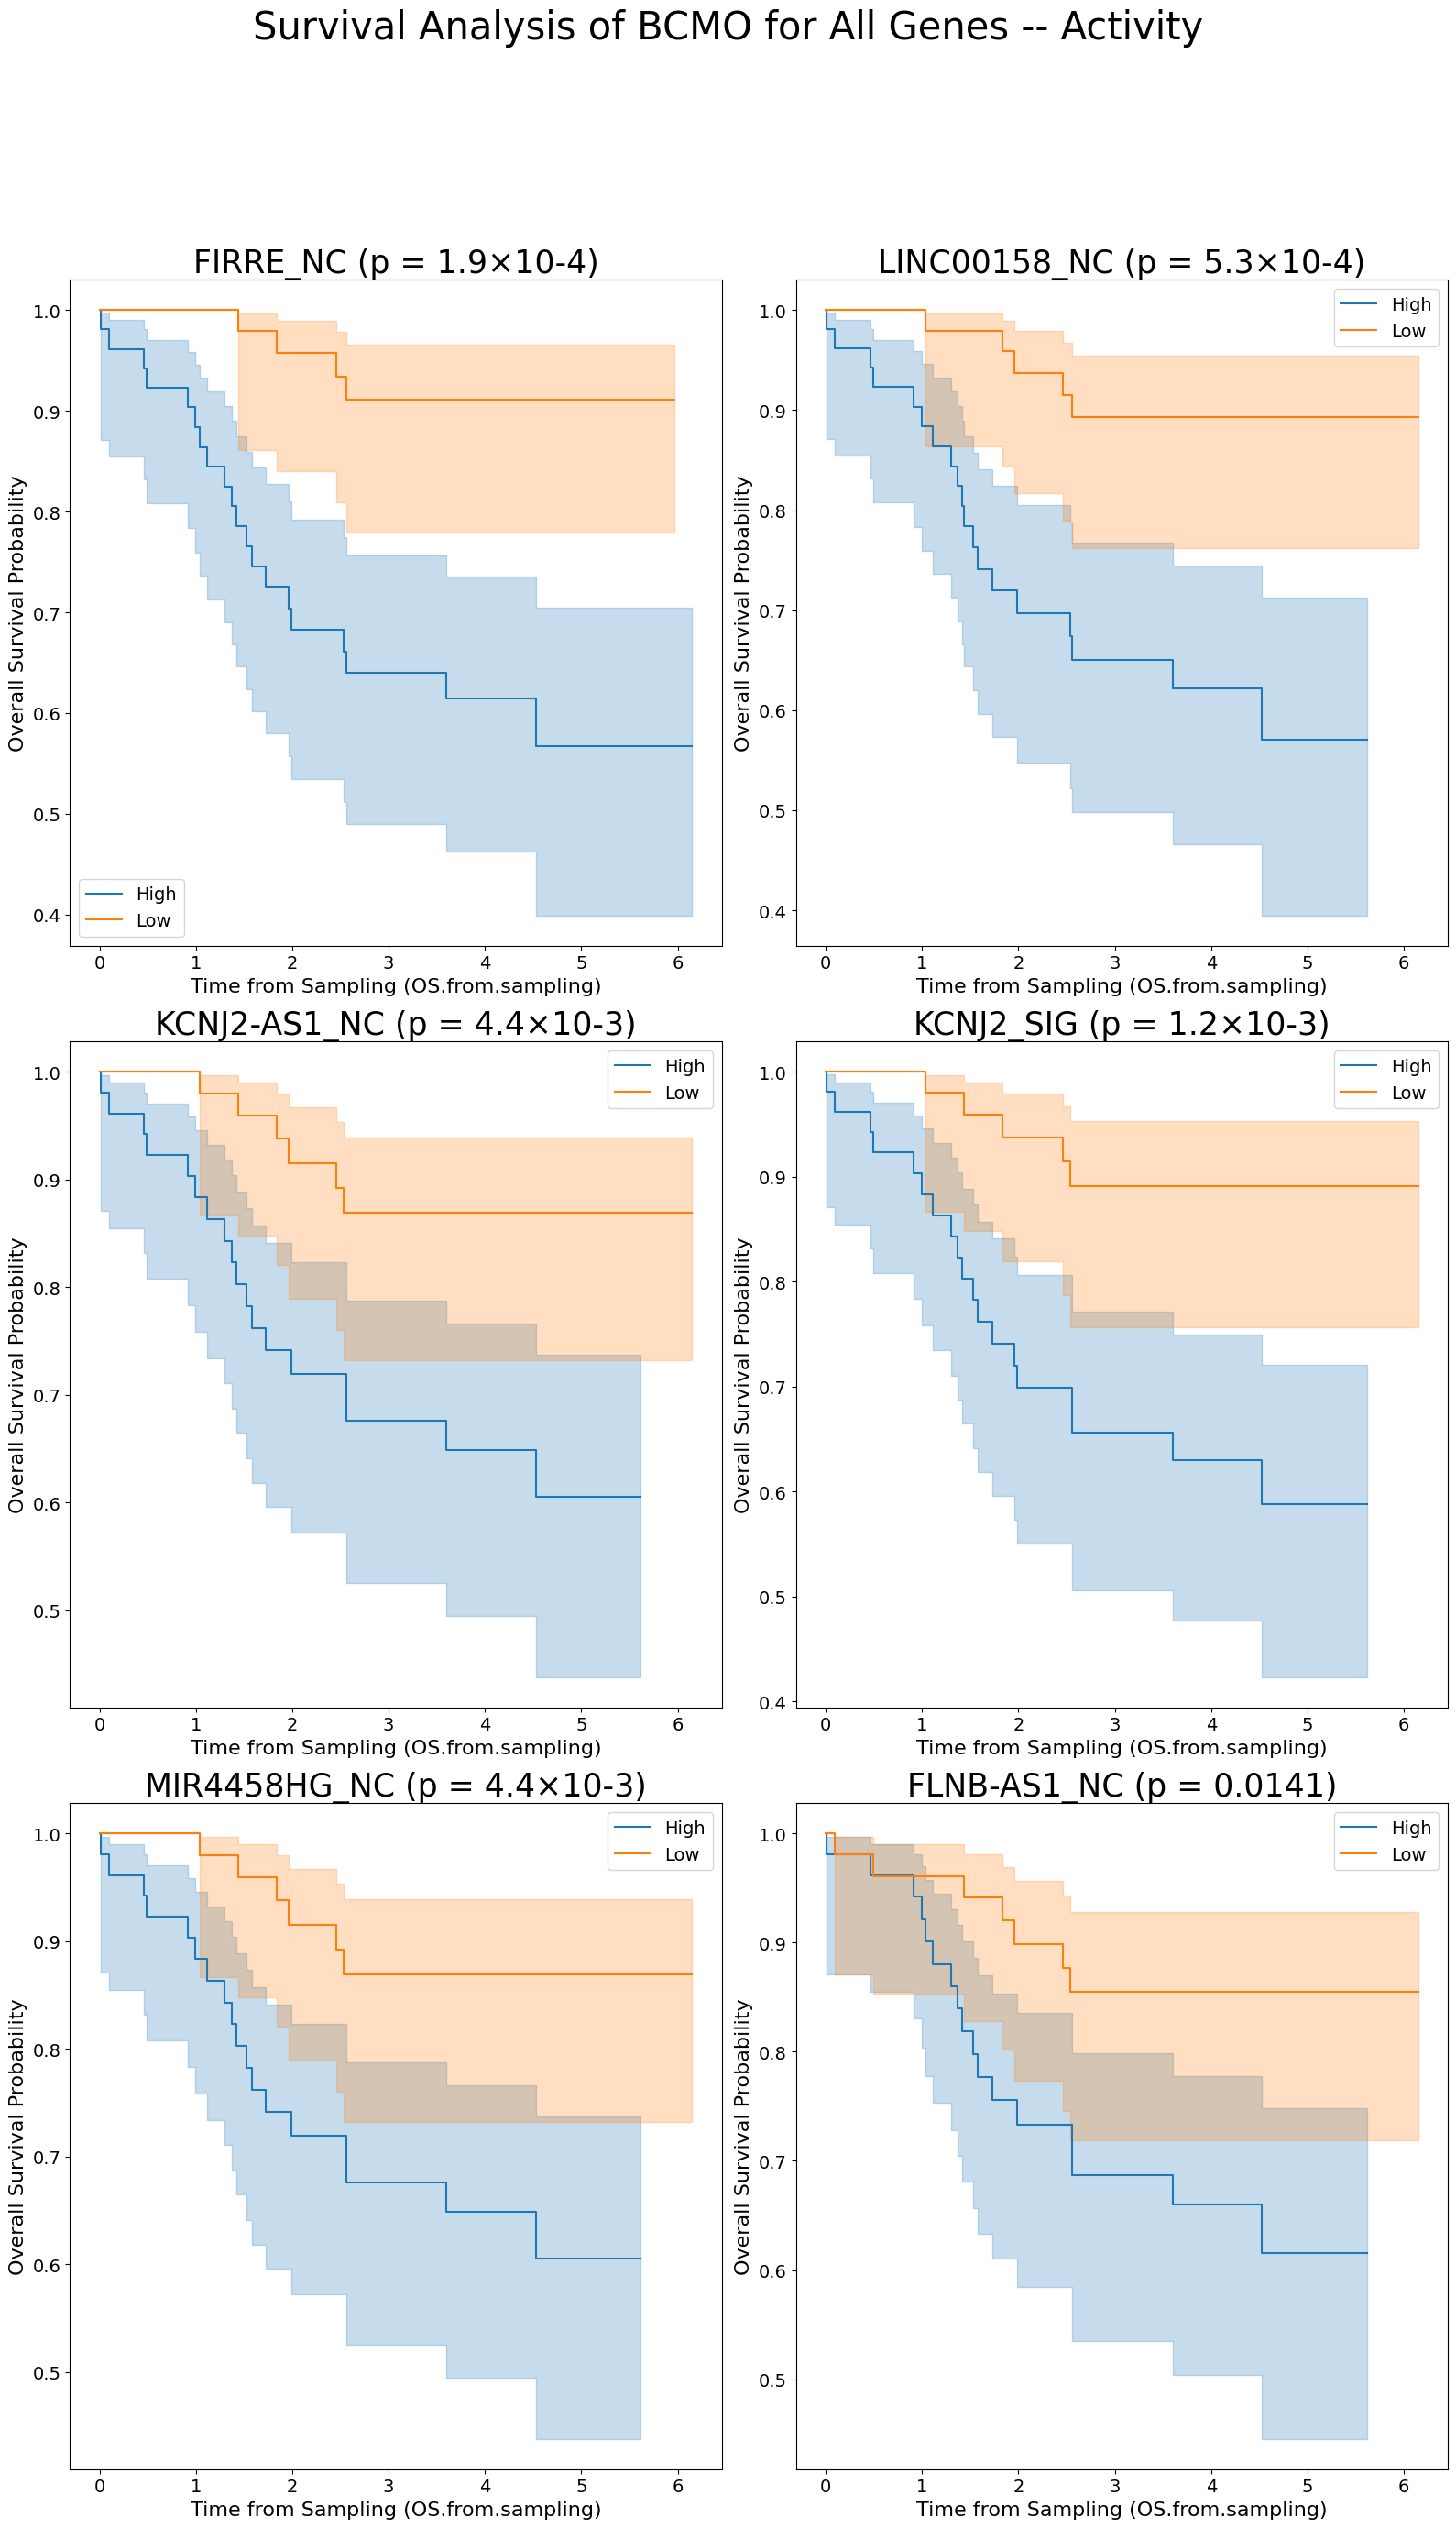

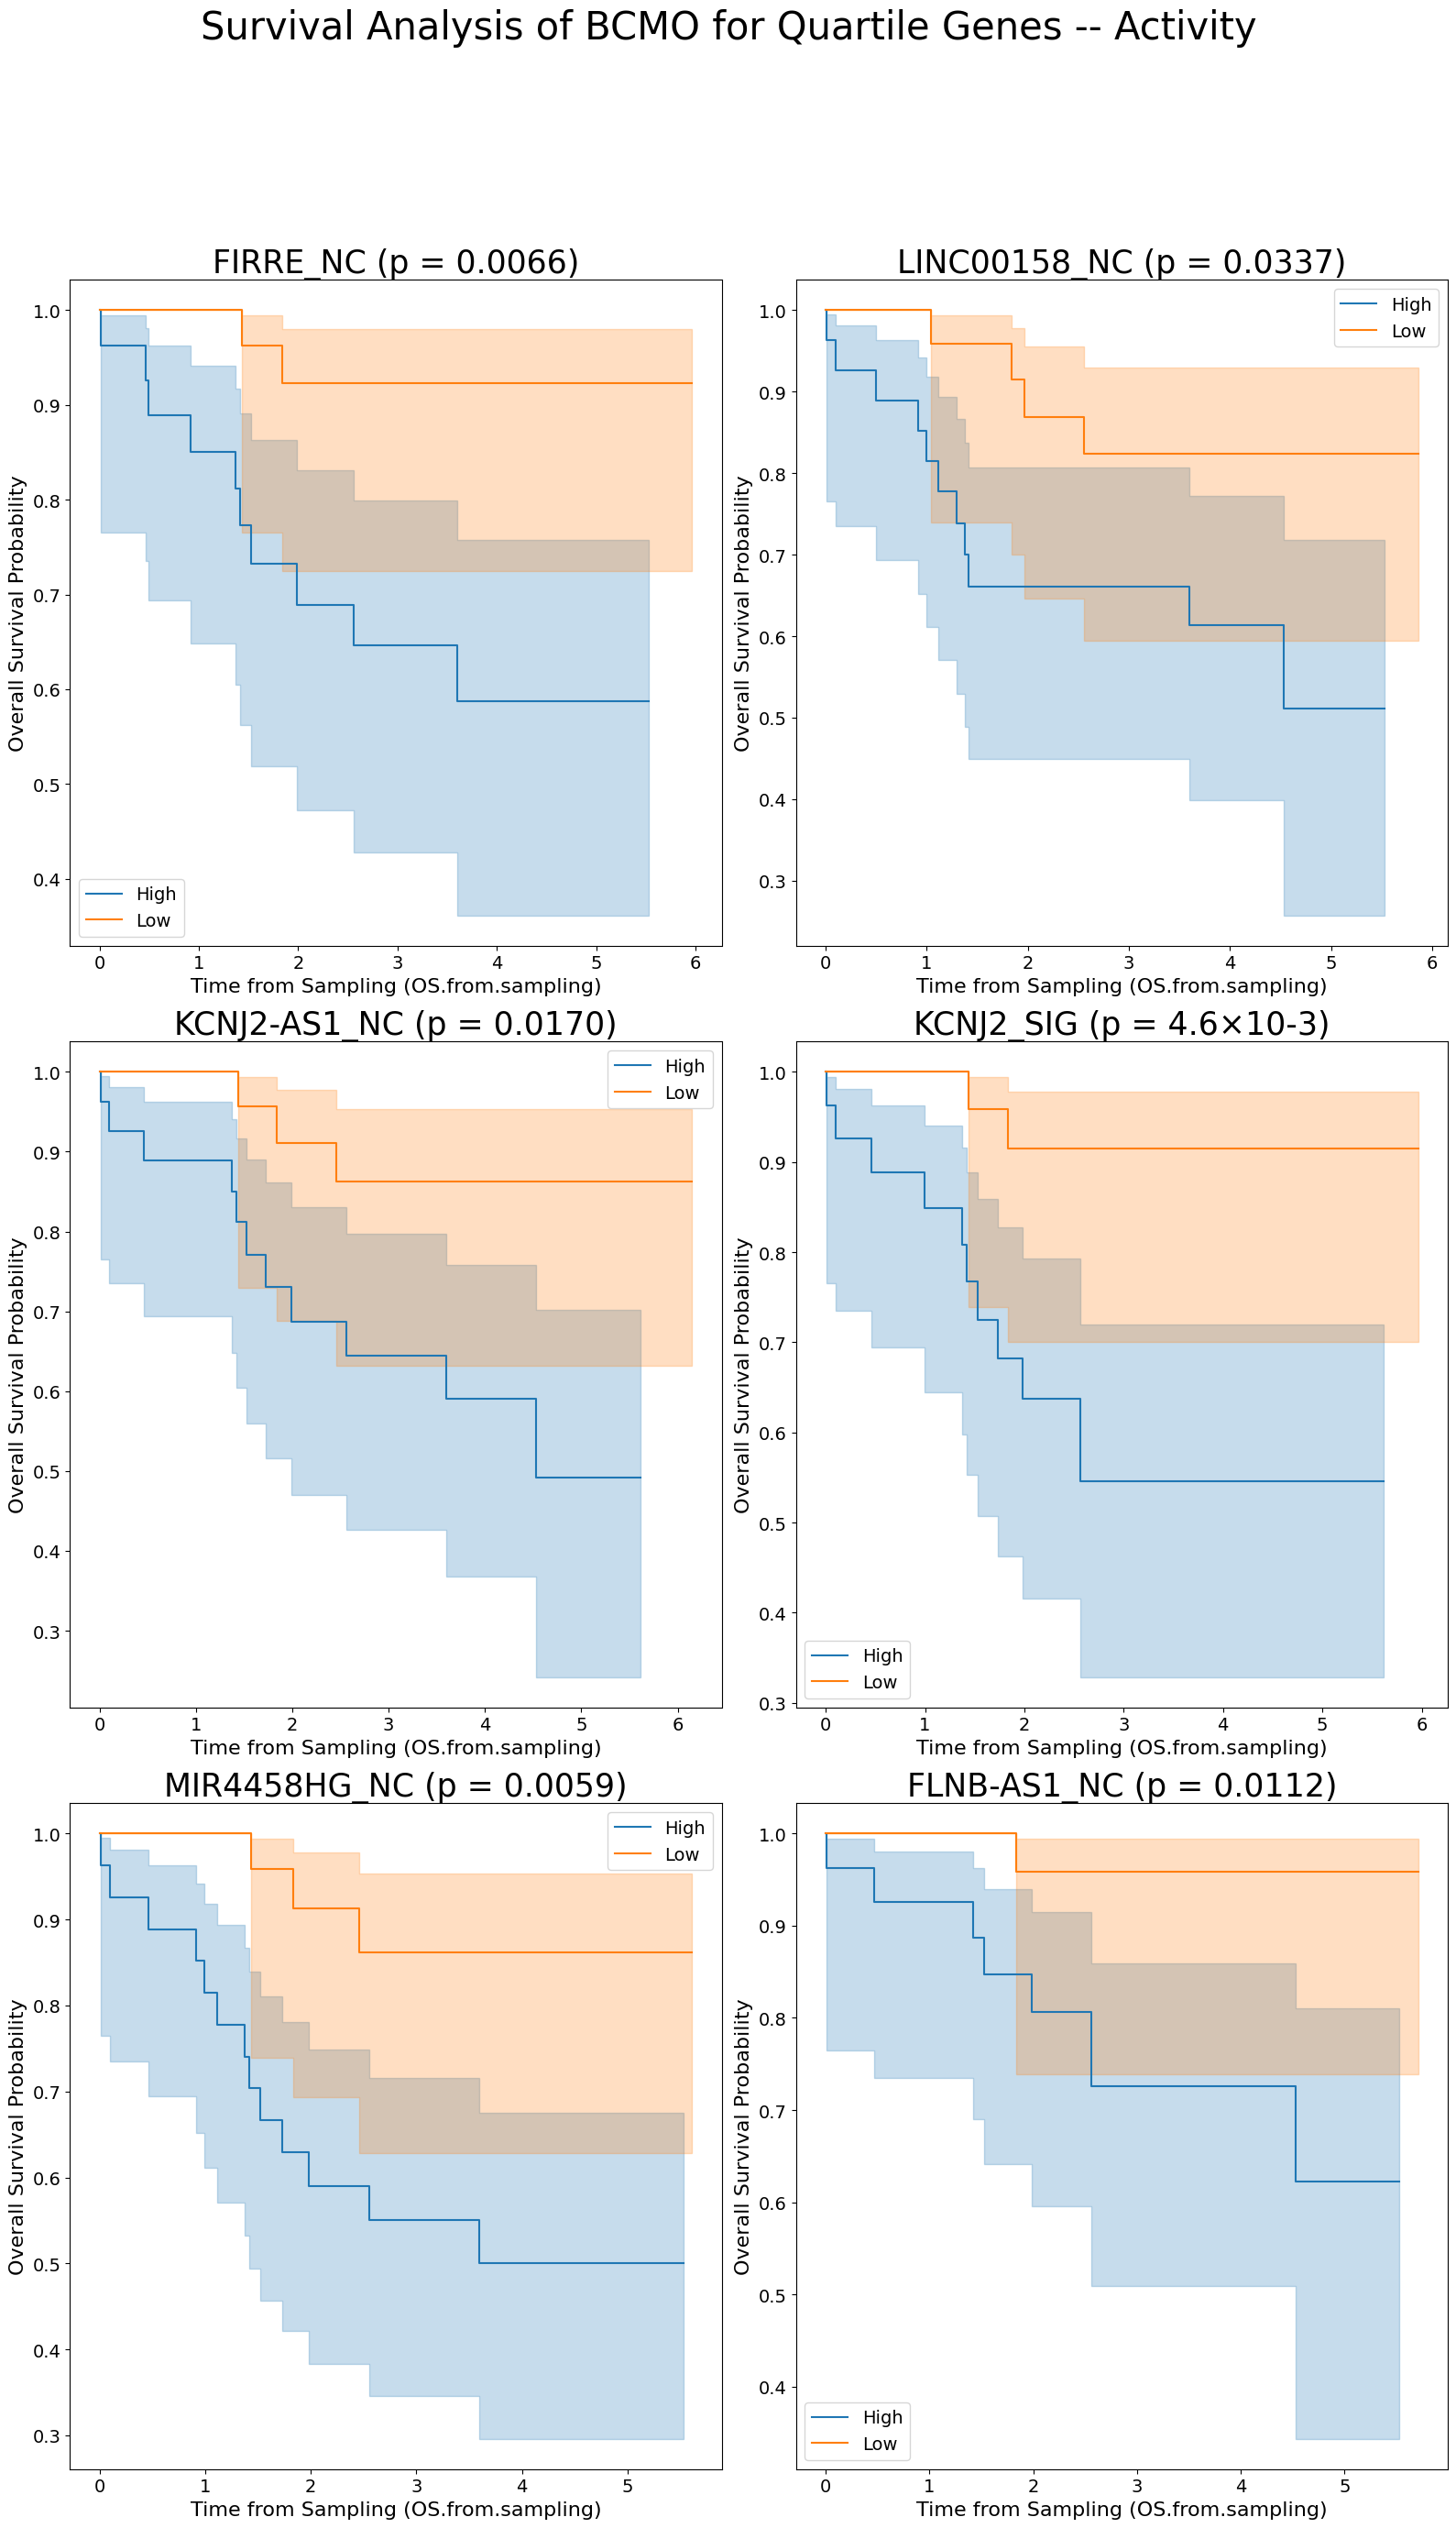

In [23]:
# Expression BCMO with all genes

genes = ["FIRRE", "LINC00158", "KCNJ2-AS1", "KCNJ2", "MIR4458HG", "FLNB-AS1"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/count_matrix.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_all_genes_BCMO_expression.png",
    split_method="median",
    fig_title="Survival Analysis of BCMO for All Genes -- Expression",
    time_col="OS.from.sampling"
)

# Expression BCMO with quartile genes

genes = ["FIRRE", "LINC00158", "KCNJ2-AS1", "KCNJ2", "MIR4458HG", "FLNB-AS1"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/count_matrix.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_quartile_genes_BCMO_expression.png",
    split_method="quartile",
    fig_title="Survival Analysis of BCMO for Quartile Genes -- Expression",
    time_col="OS.from.sampling"
)

# Activity BCMO with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "KCNJ2_SIG", "MIR4458HG_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_all_genes_BCMO_activity.png",
    split_method="median",
    fig_title="Survival Analysis of BCMO for All Genes -- Activity",
    time_col="OS.from.sampling"
)

# Activity BCMO with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "KCNJ2_SIG", "MIR4458HG_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_quartile_genes_BCMO_activity.png",
    split_method="quartile",
    fig_title="Survival Analysis of BCMO for Quartile Genes -- Activity",
    time_col="OS.from.sampling"
)

In [10]:
# For TFT.(from.diagnosis?)

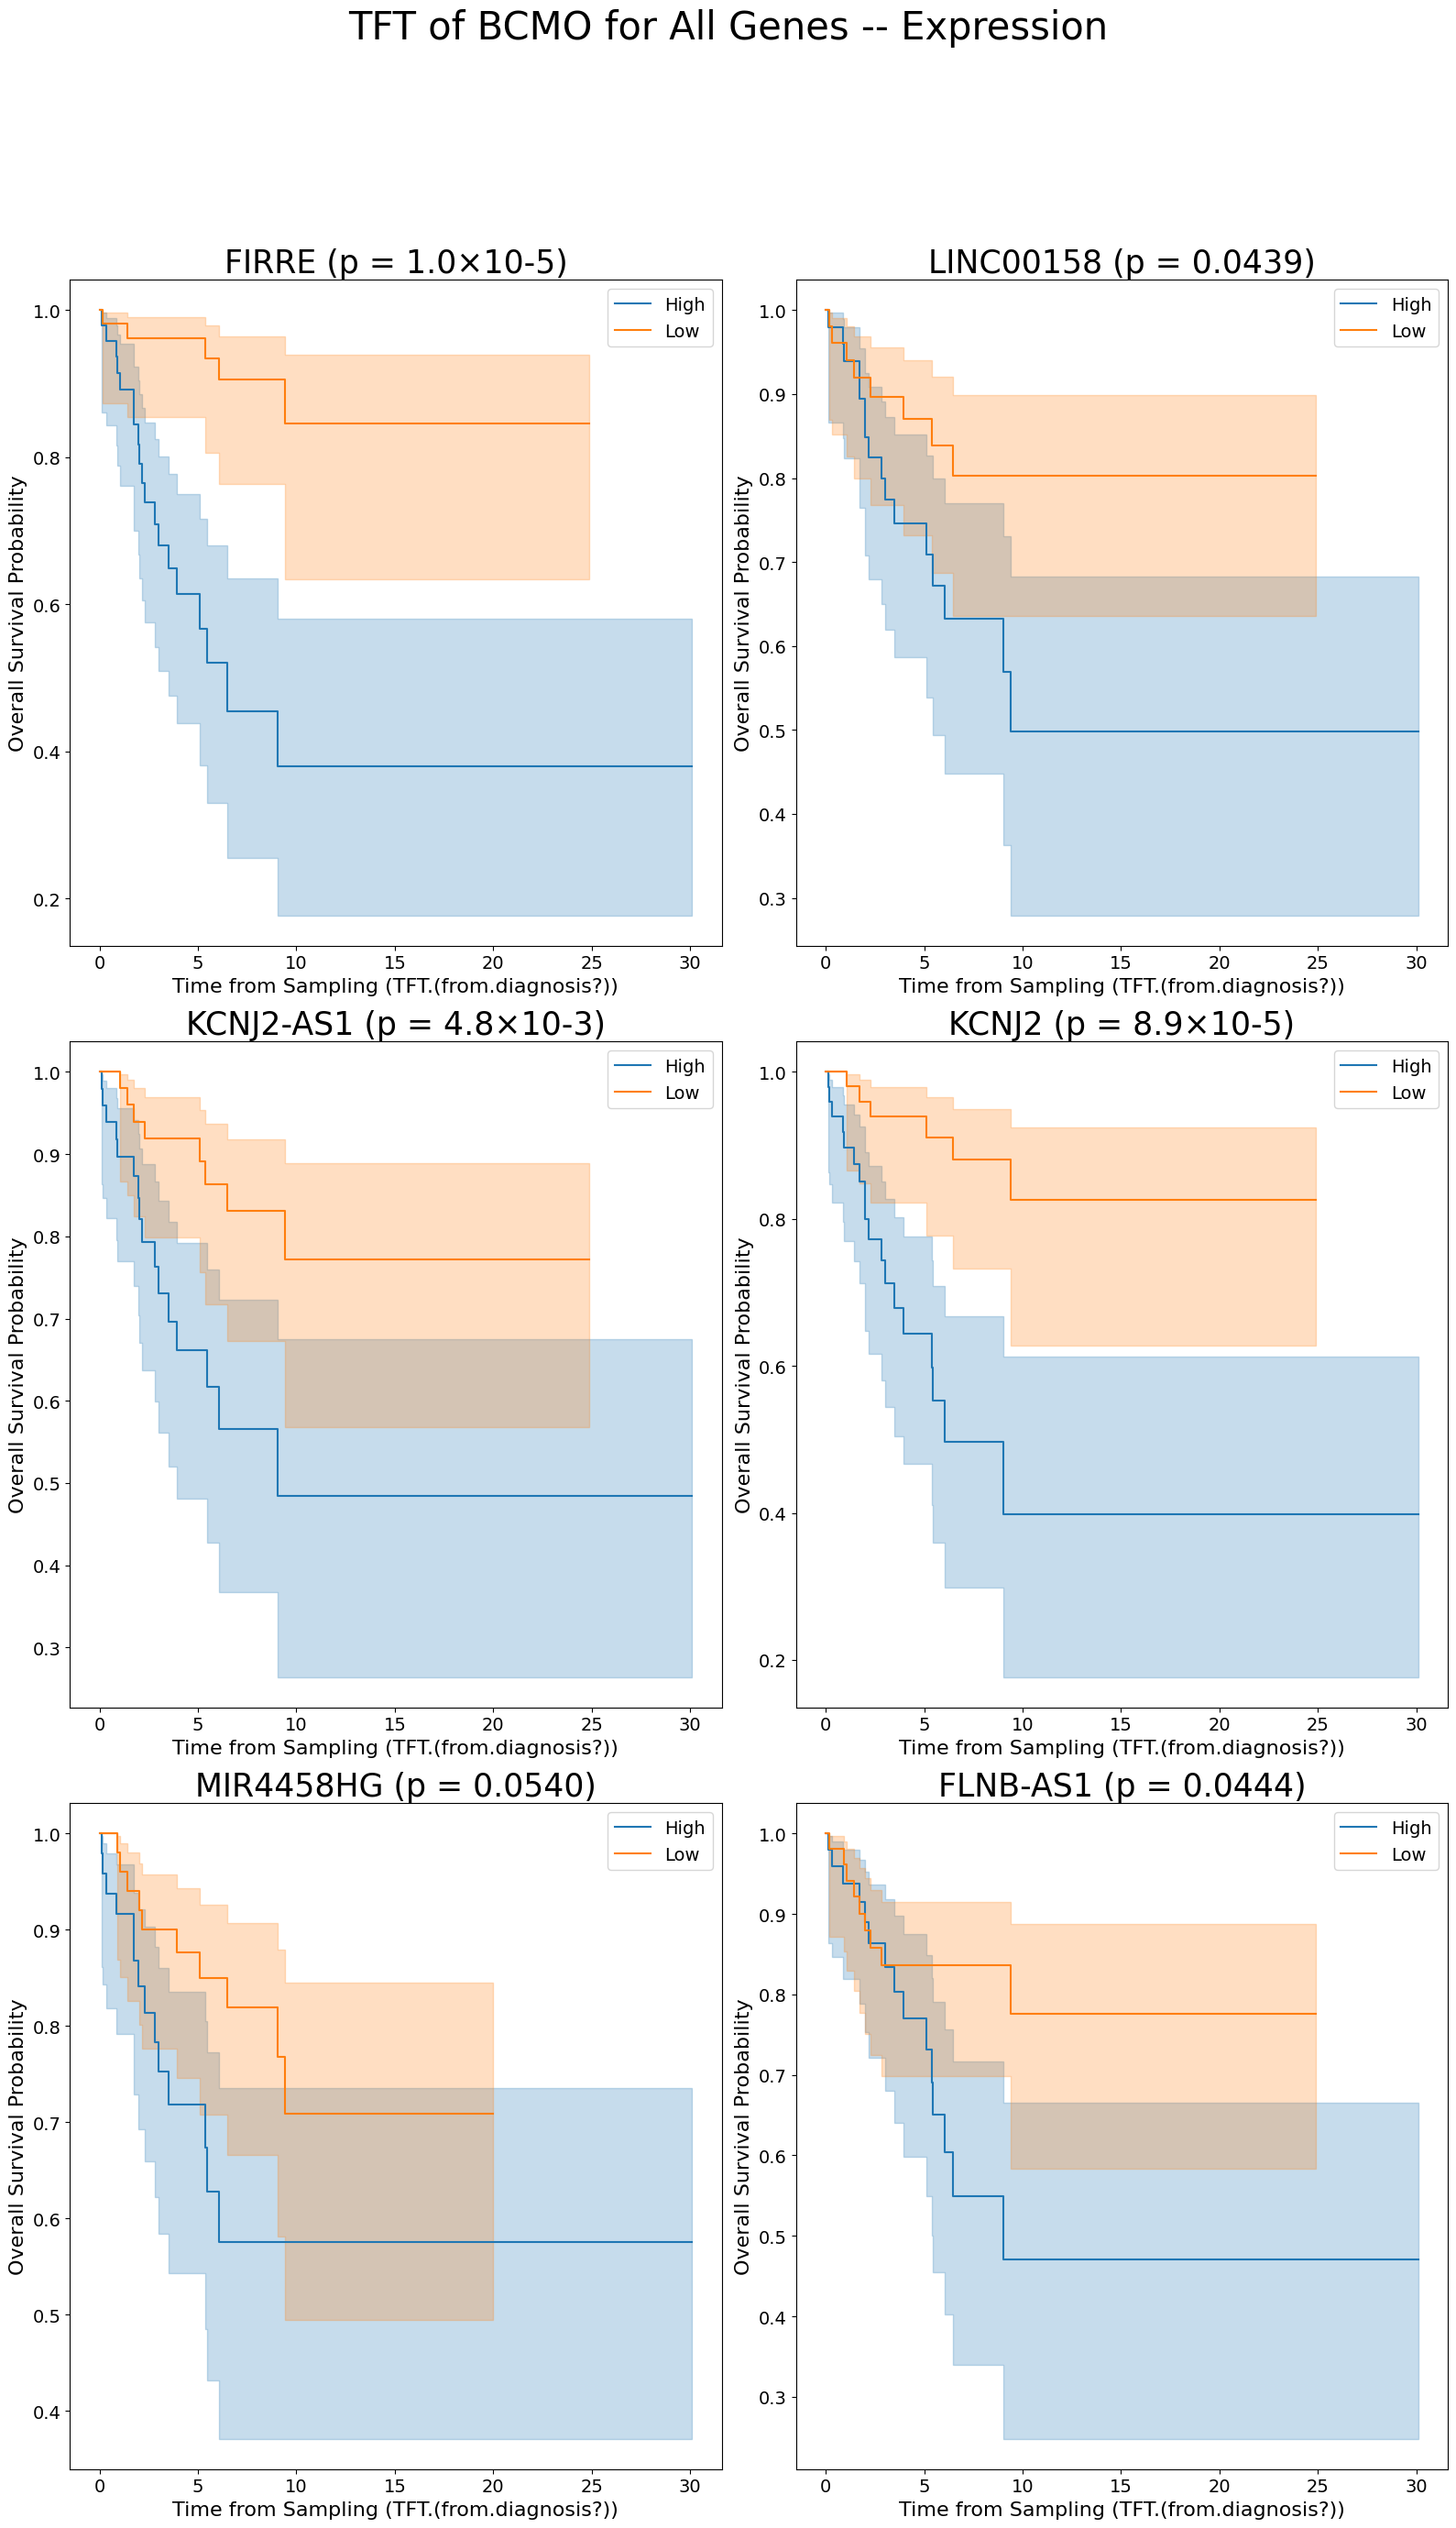

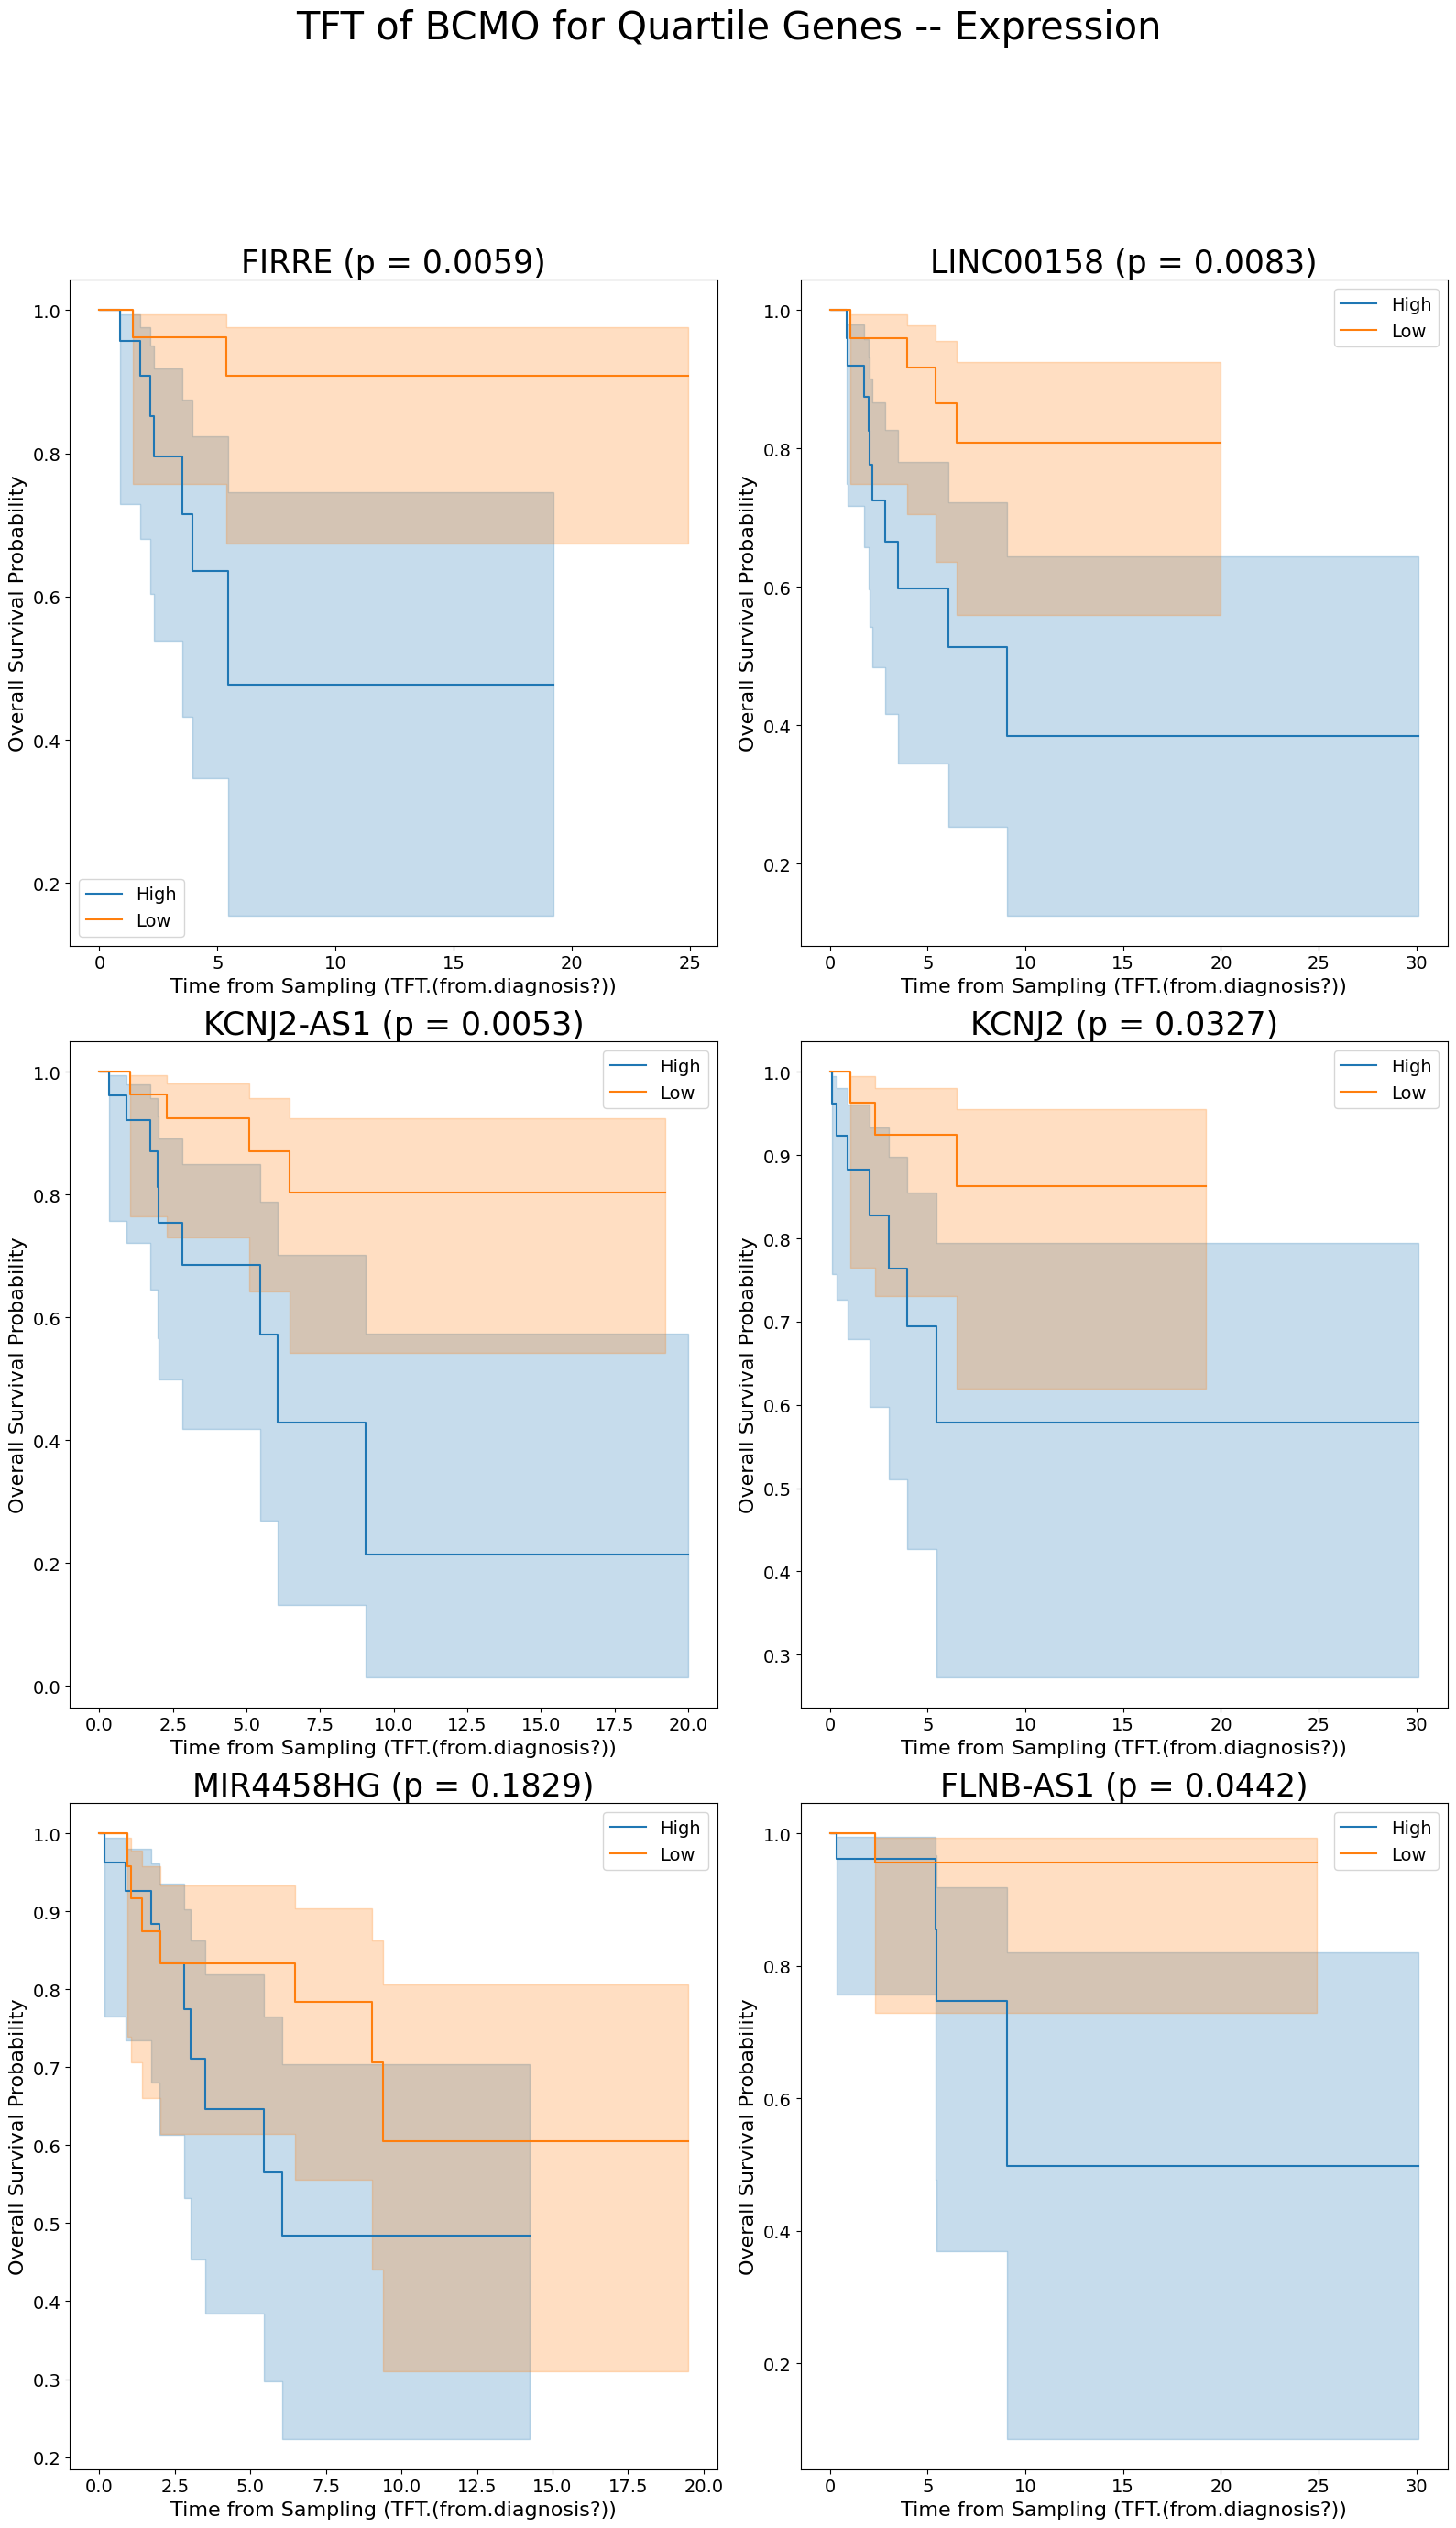

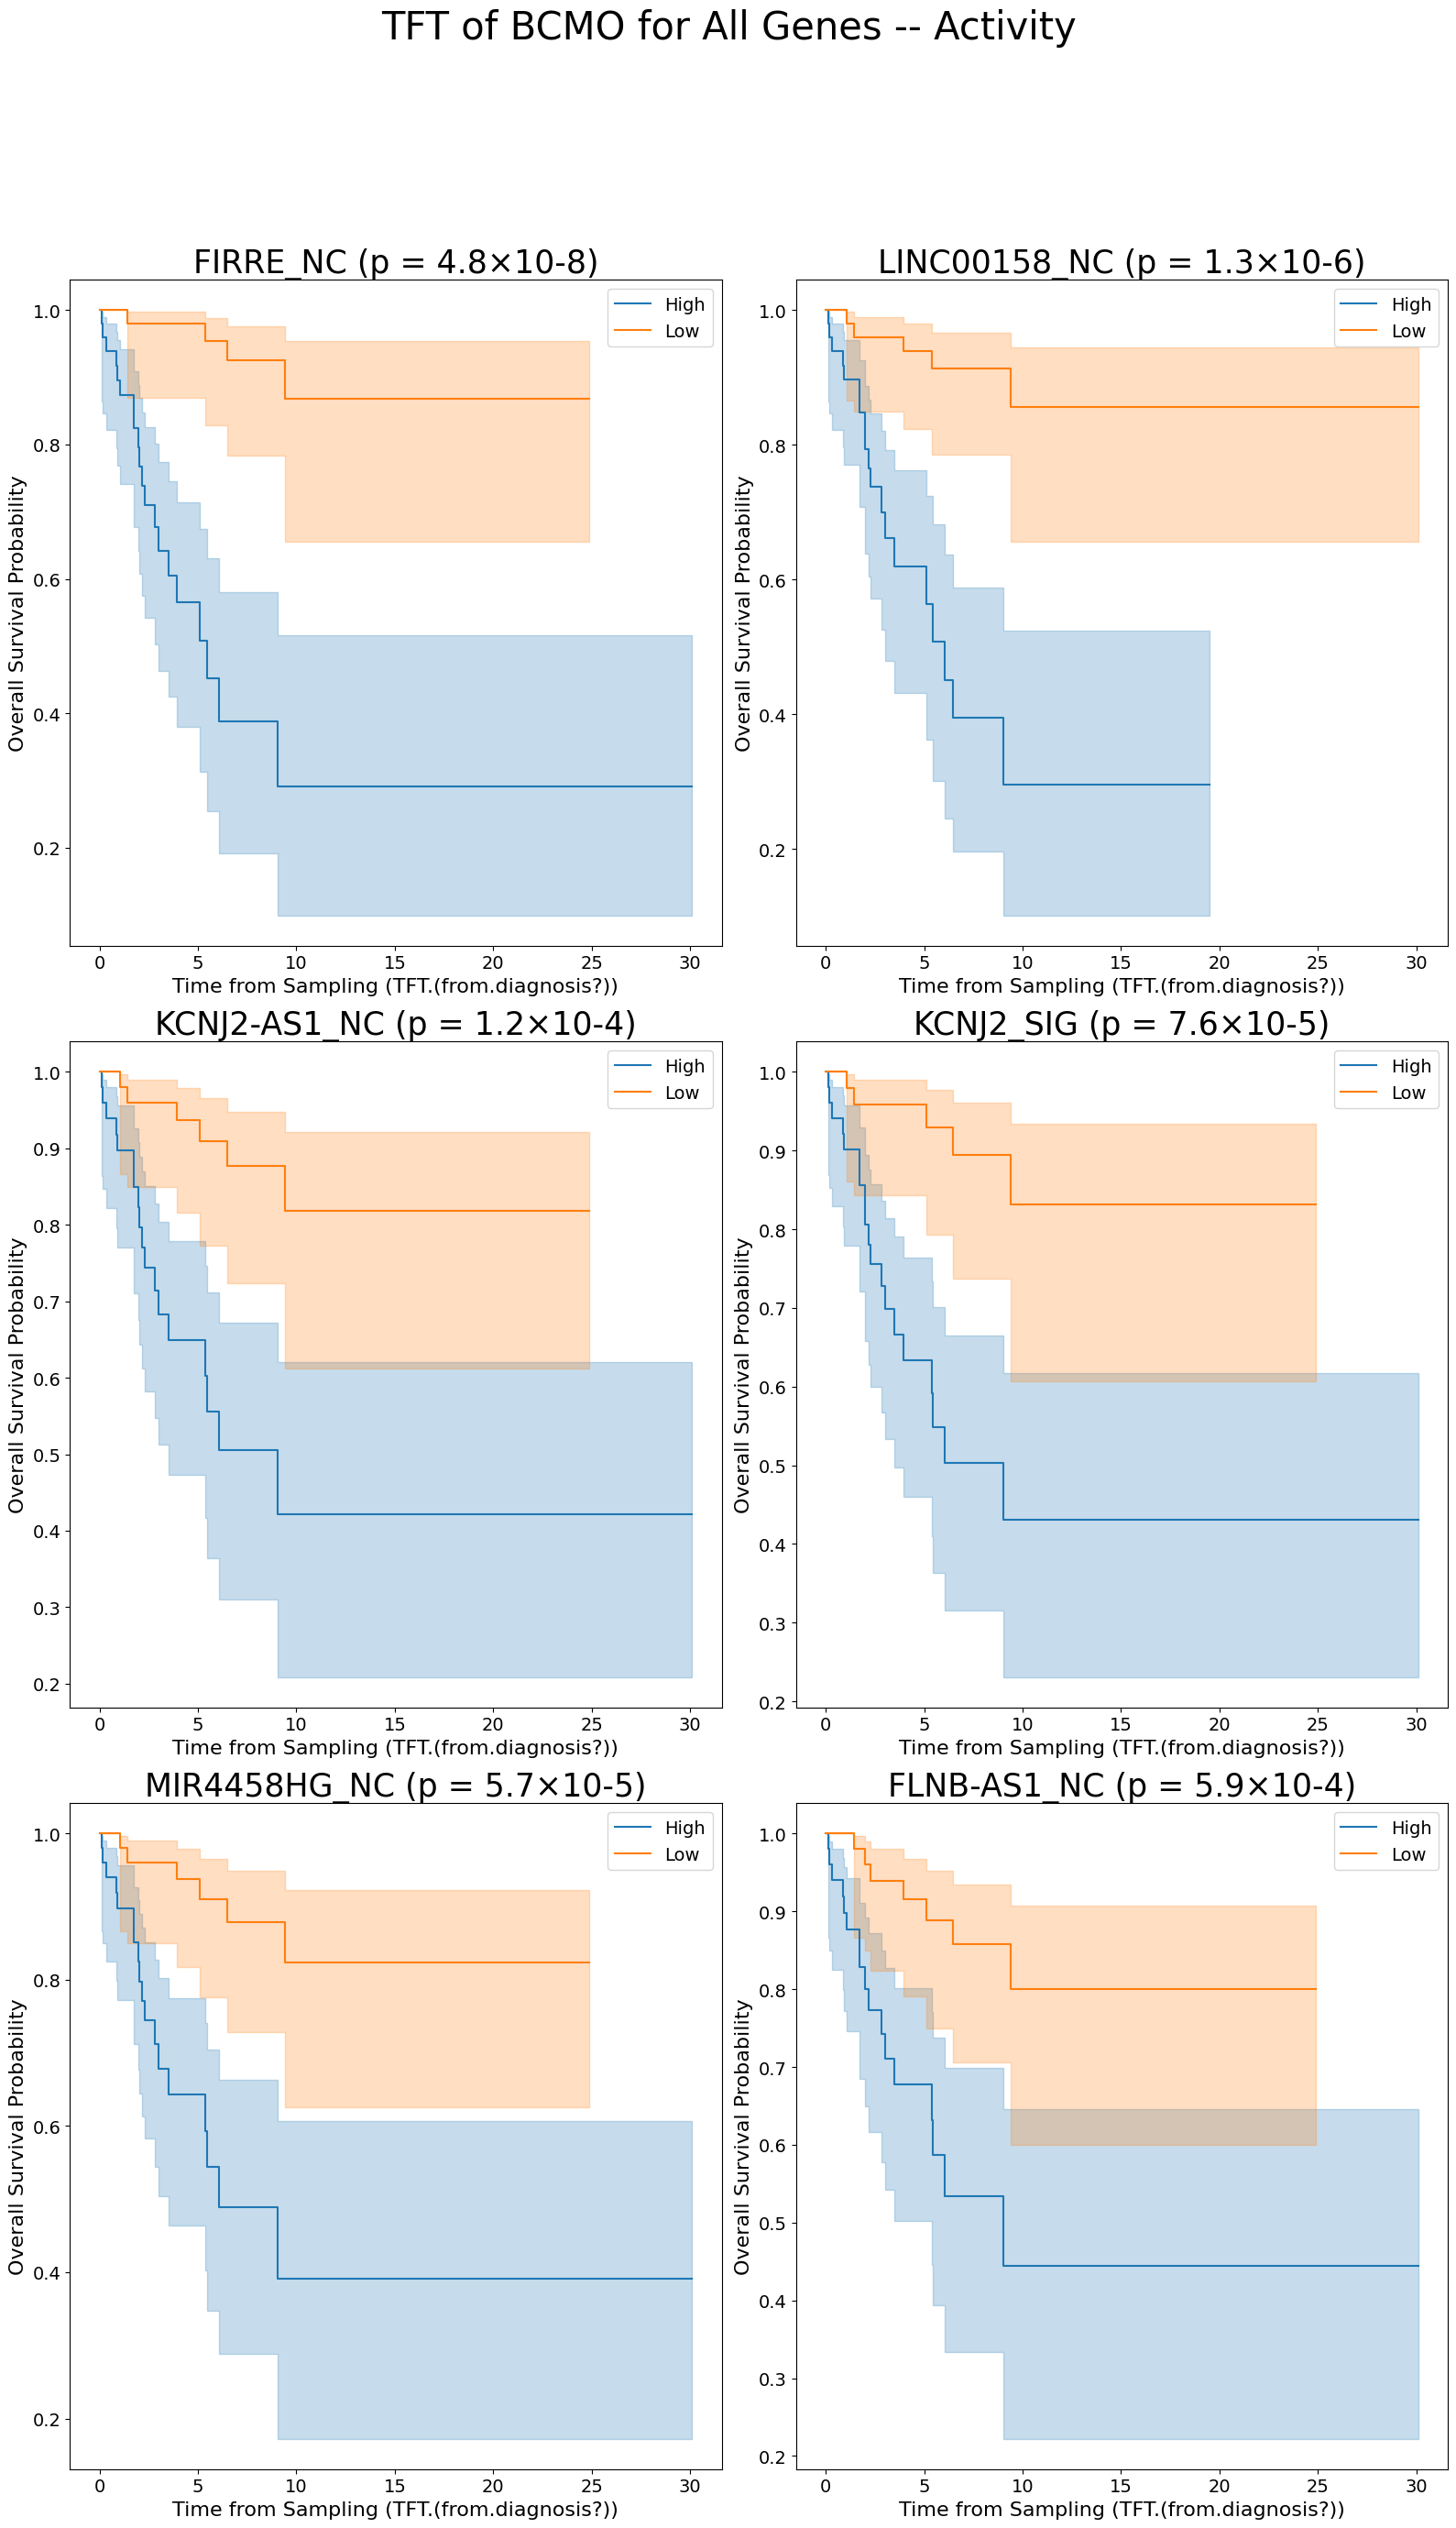

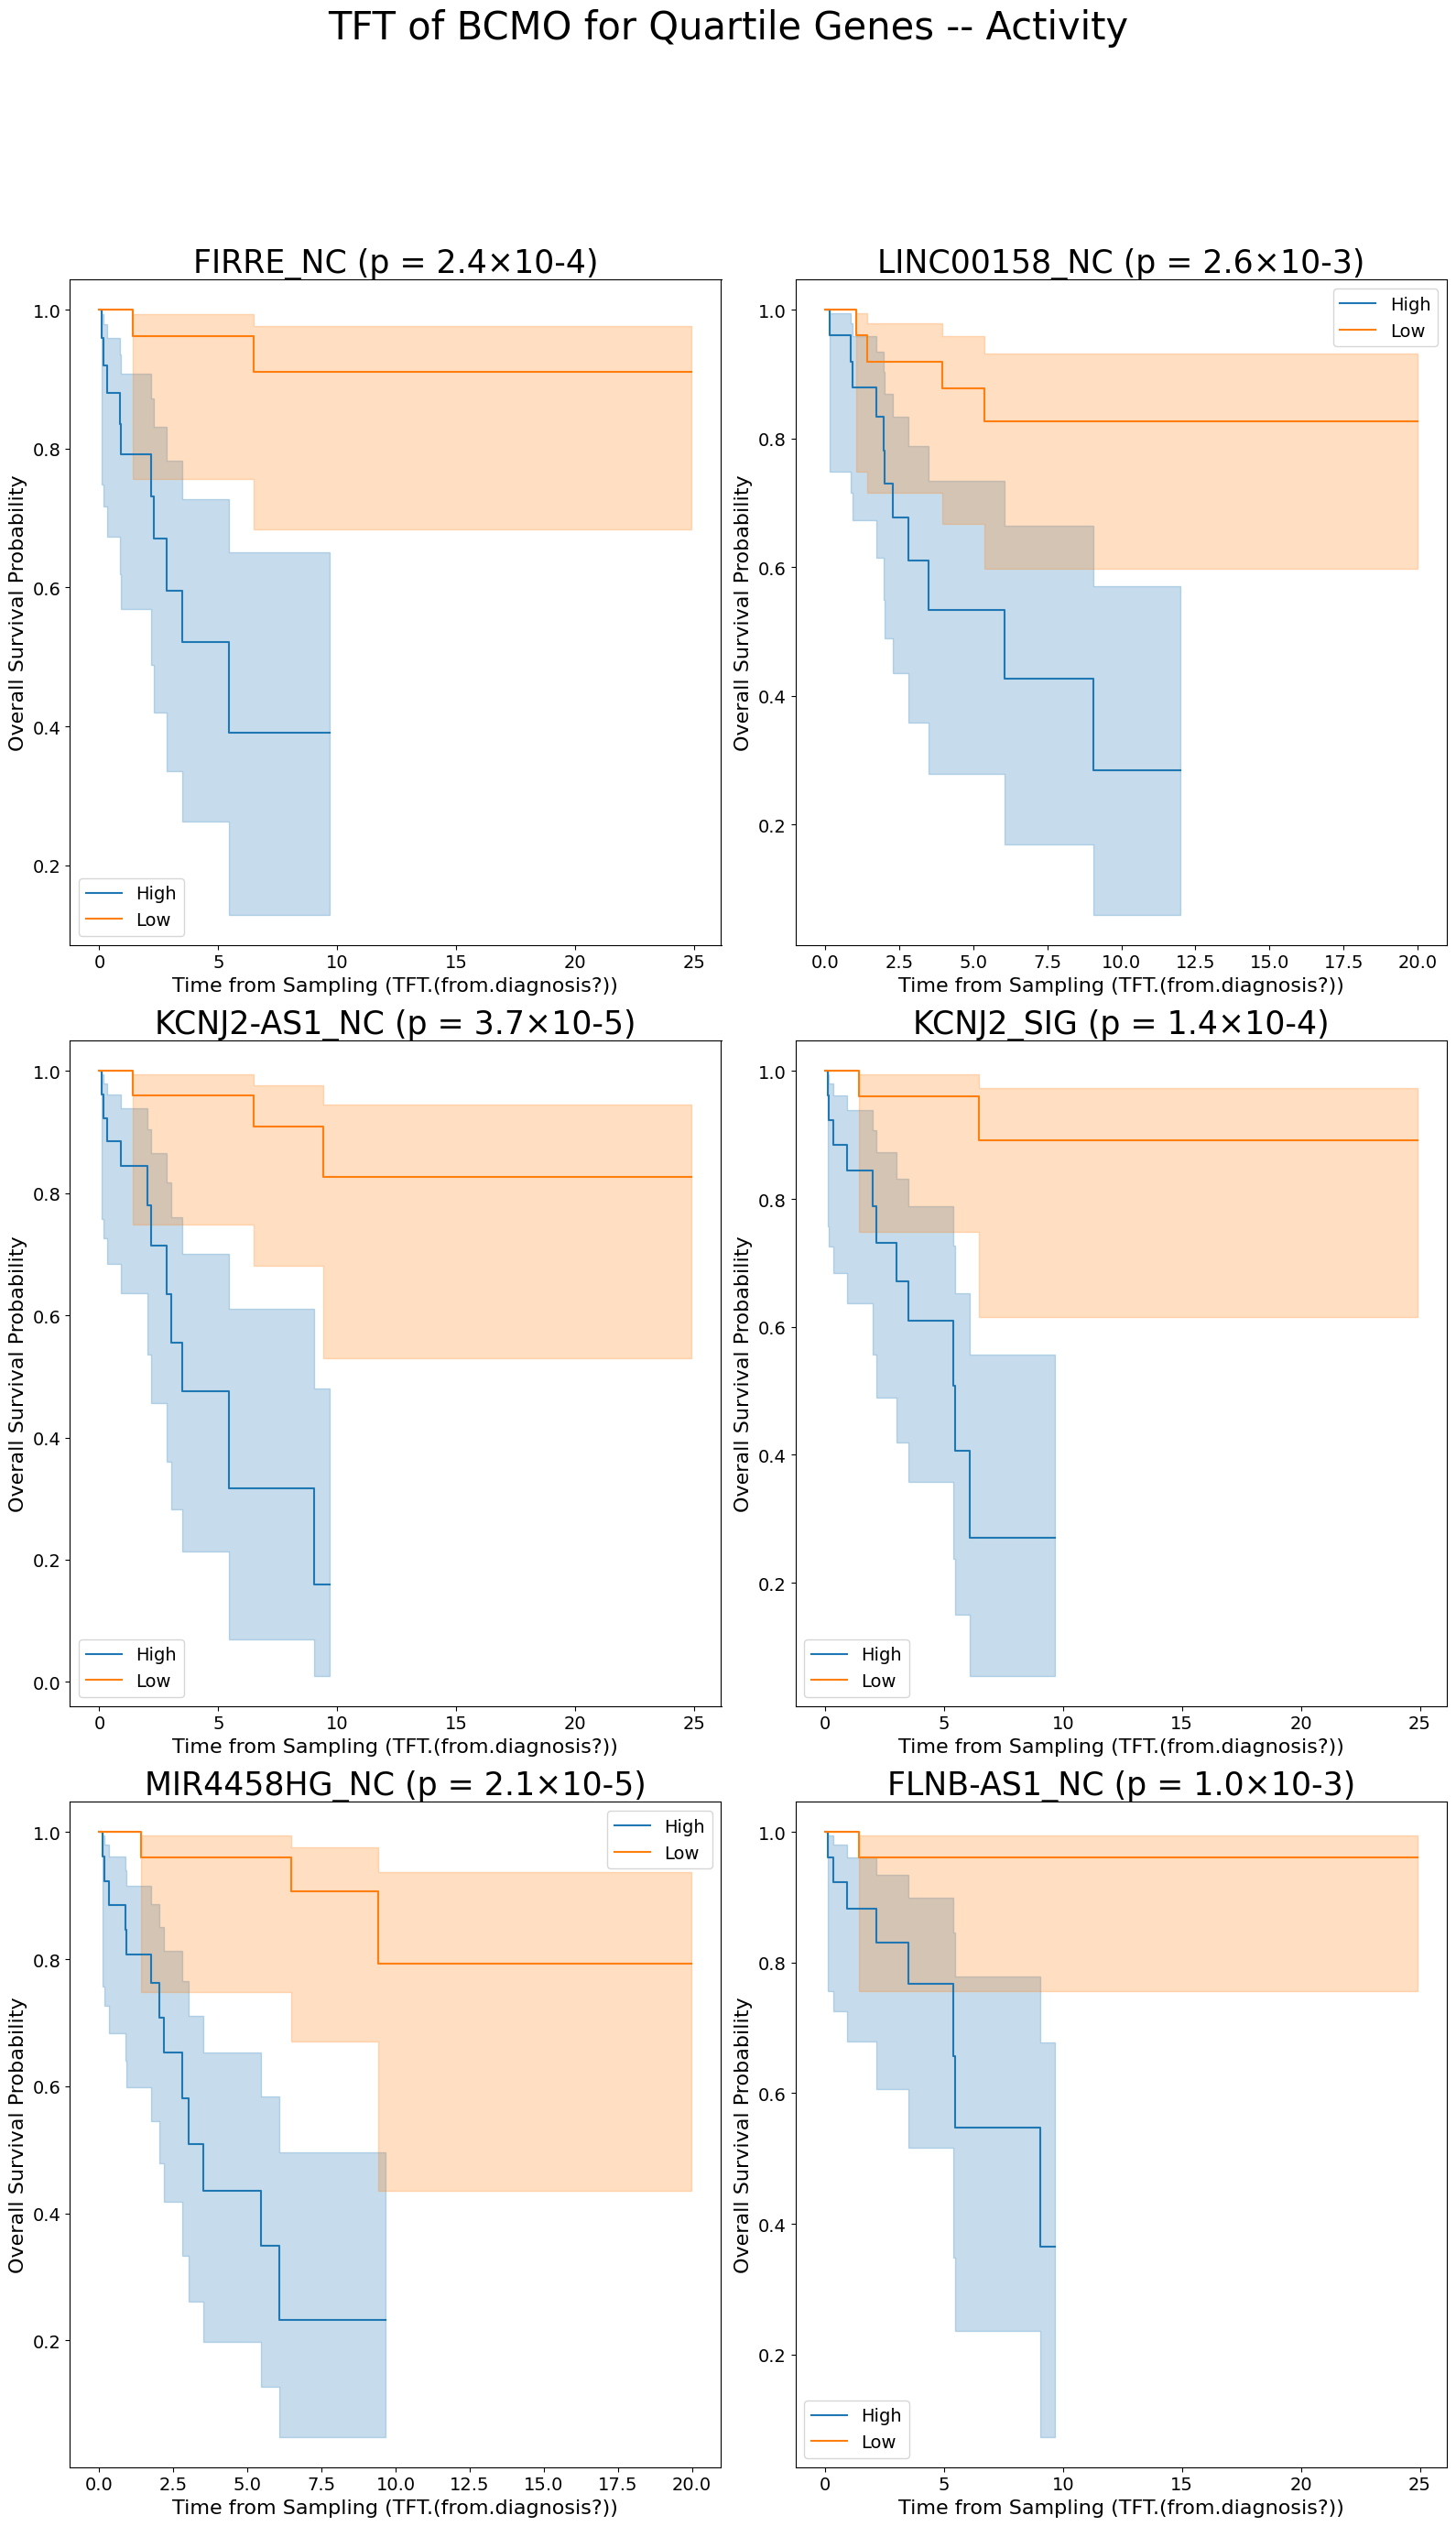

In [24]:
# Expression BCMO with all genes

genes = ["FIRRE", "LINC00158", "KCNJ2-AS1", "KCNJ2", "MIR4458HG", "FLNB-AS1"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/count_matrix.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_TFT_all_genes_BCMO_expression.png",
    split_method="median",
    fig_title="TFT of BCMO for All Genes -- Expression",
    time_col="TFT.(from.diagnosis?)"
)

# Expression BCMO with quartile genes

genes = ["FIRRE", "LINC00158", "KCNJ2-AS1", "KCNJ2", "MIR4458HG", "FLNB-AS1"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/count_matrix.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_TFT_quartile_genes_BCMO_expression.png",
    split_method="quartile",
    fig_title="TFT of BCMO for Quartile Genes -- Expression",
    time_col="TFT.(from.diagnosis?)"
)

# Activity BCMO with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "KCNJ2_SIG", "MIR4458HG_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_TFT_all_genes_BCMO_activity.png",
    split_method="median",
    fig_title="TFT of BCMO for All Genes -- Activity",
    time_col="TFT.(from.diagnosis?)"
)

# Activity BCMO with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "KCNJ2_SIG", "MIR4458HG_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_TFT_quartile_genes_BCMO_activity.png",
    split_method="quartile",
    fig_title="TFT of BCMO for Quartile Genes -- Activity",
    time_col="TFT.(from.diagnosis?)"
)

In [12]:
# For TTT.from.sampling

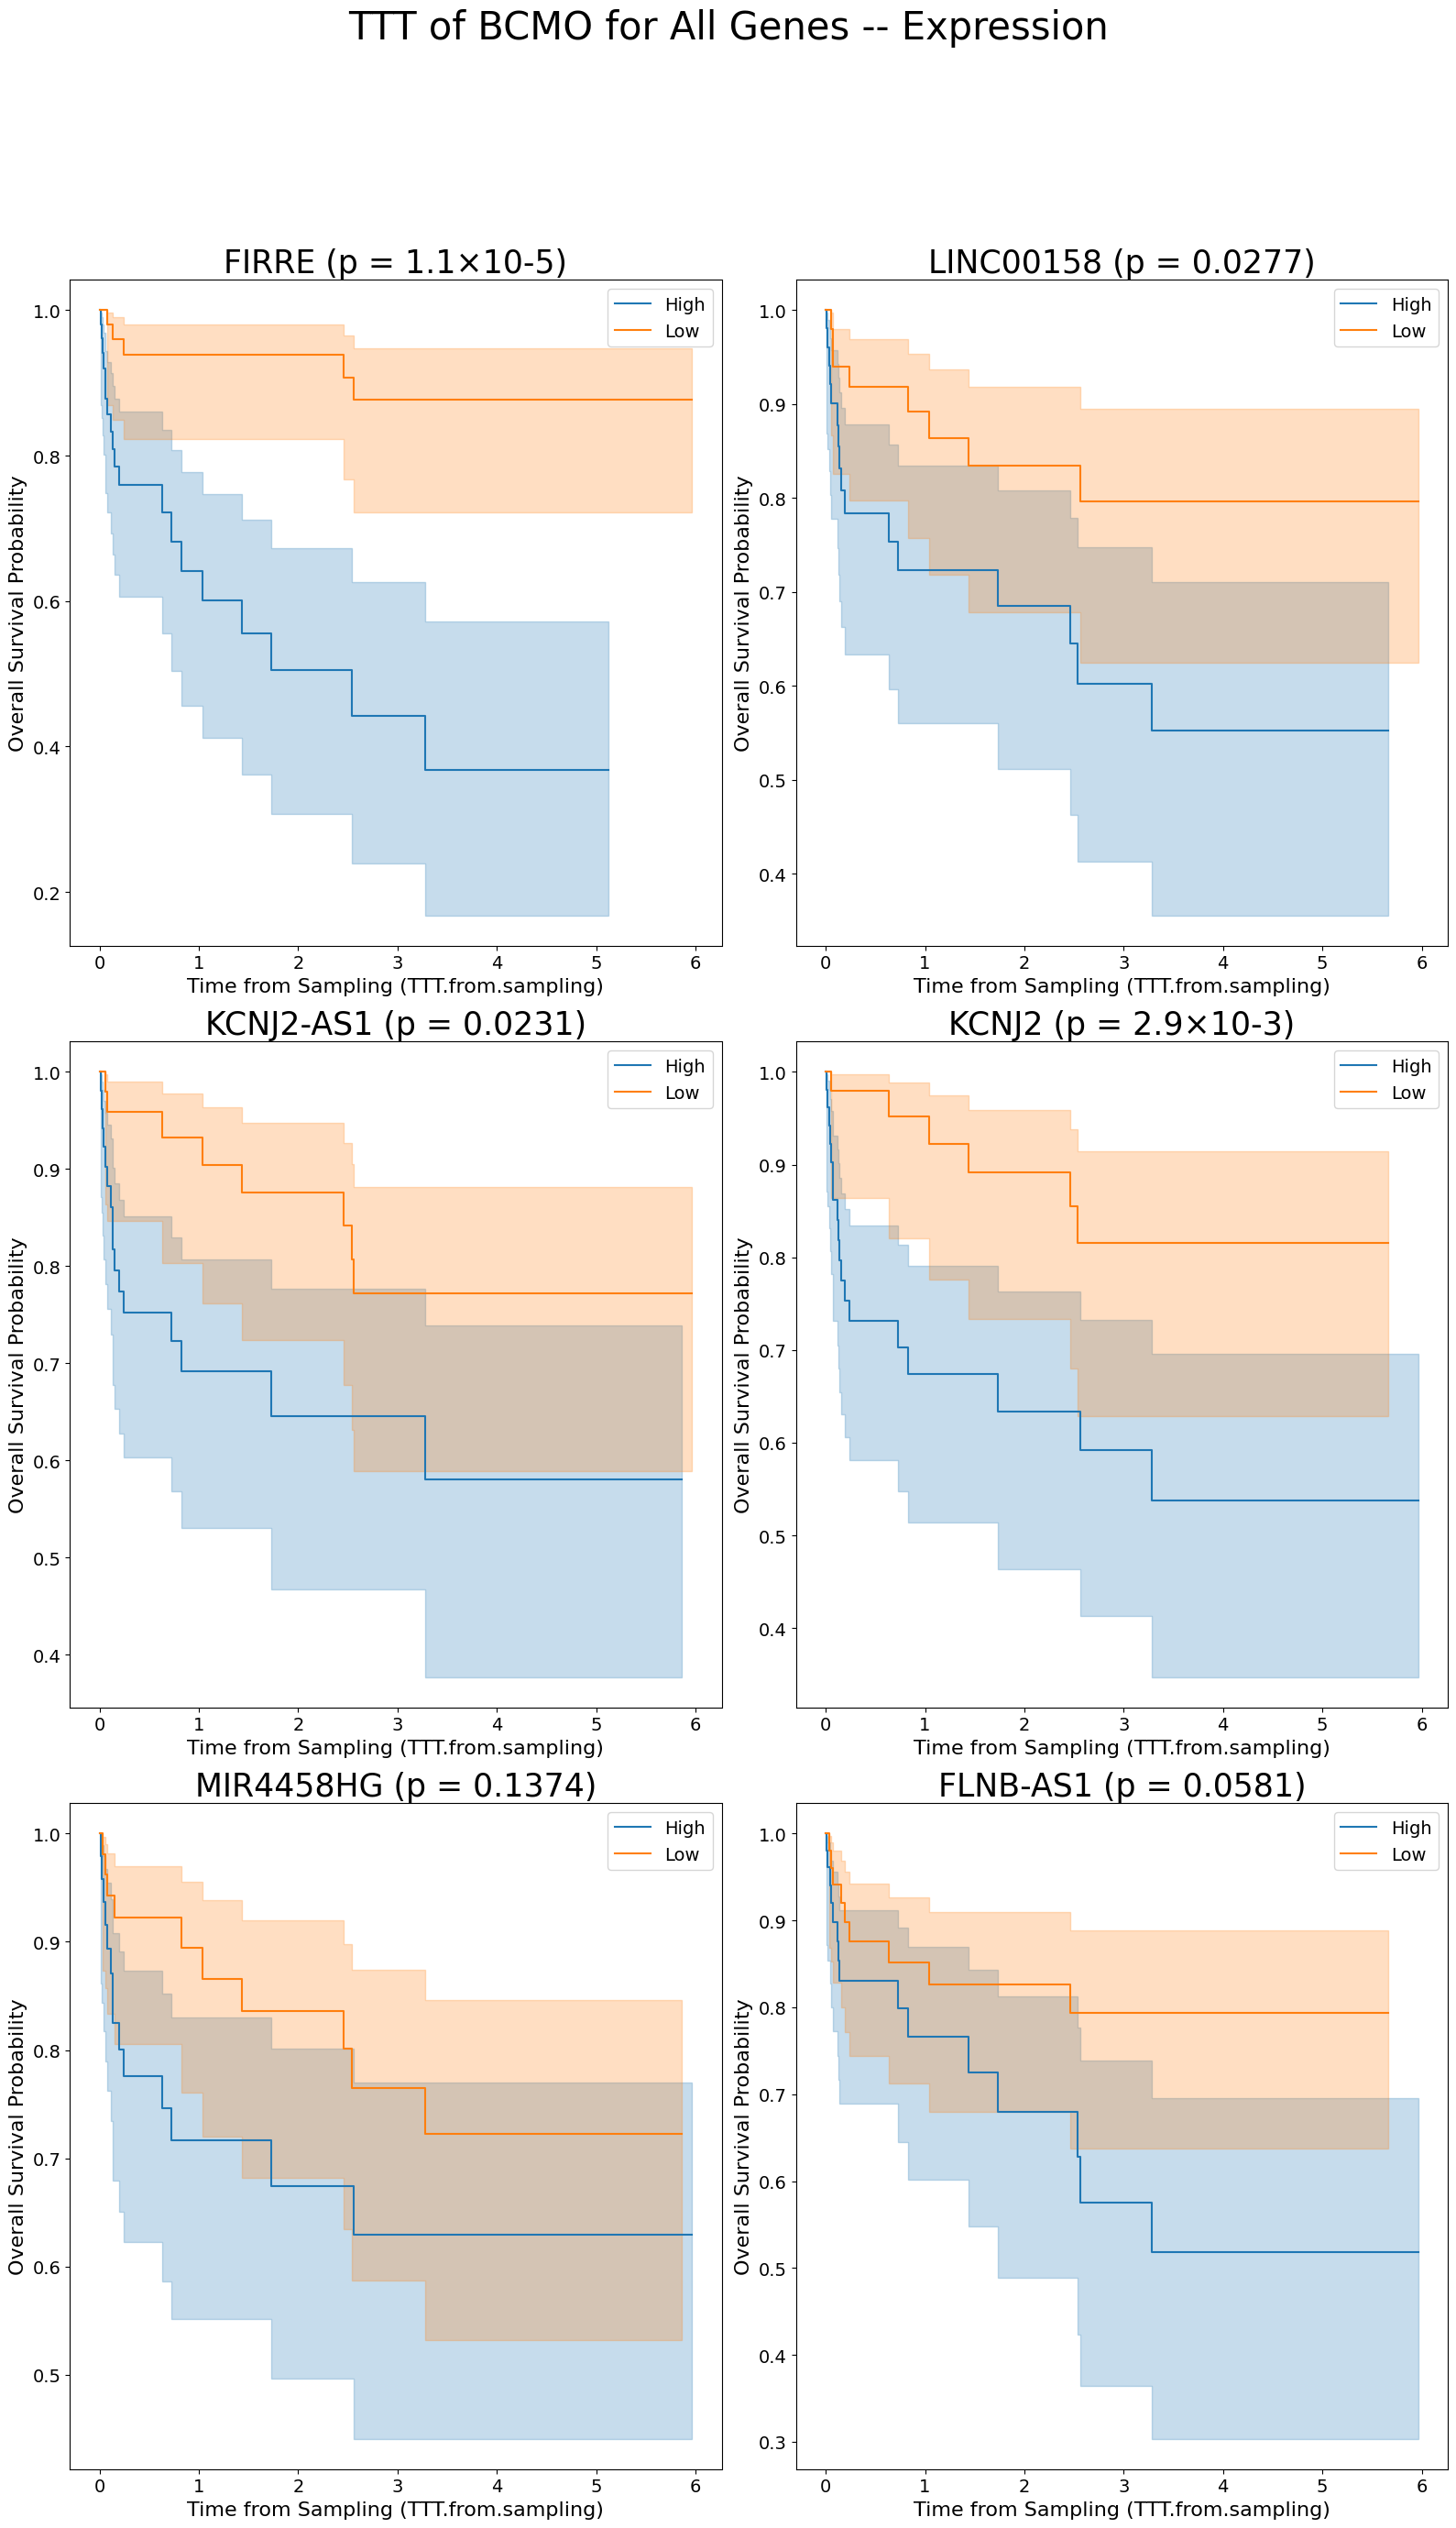

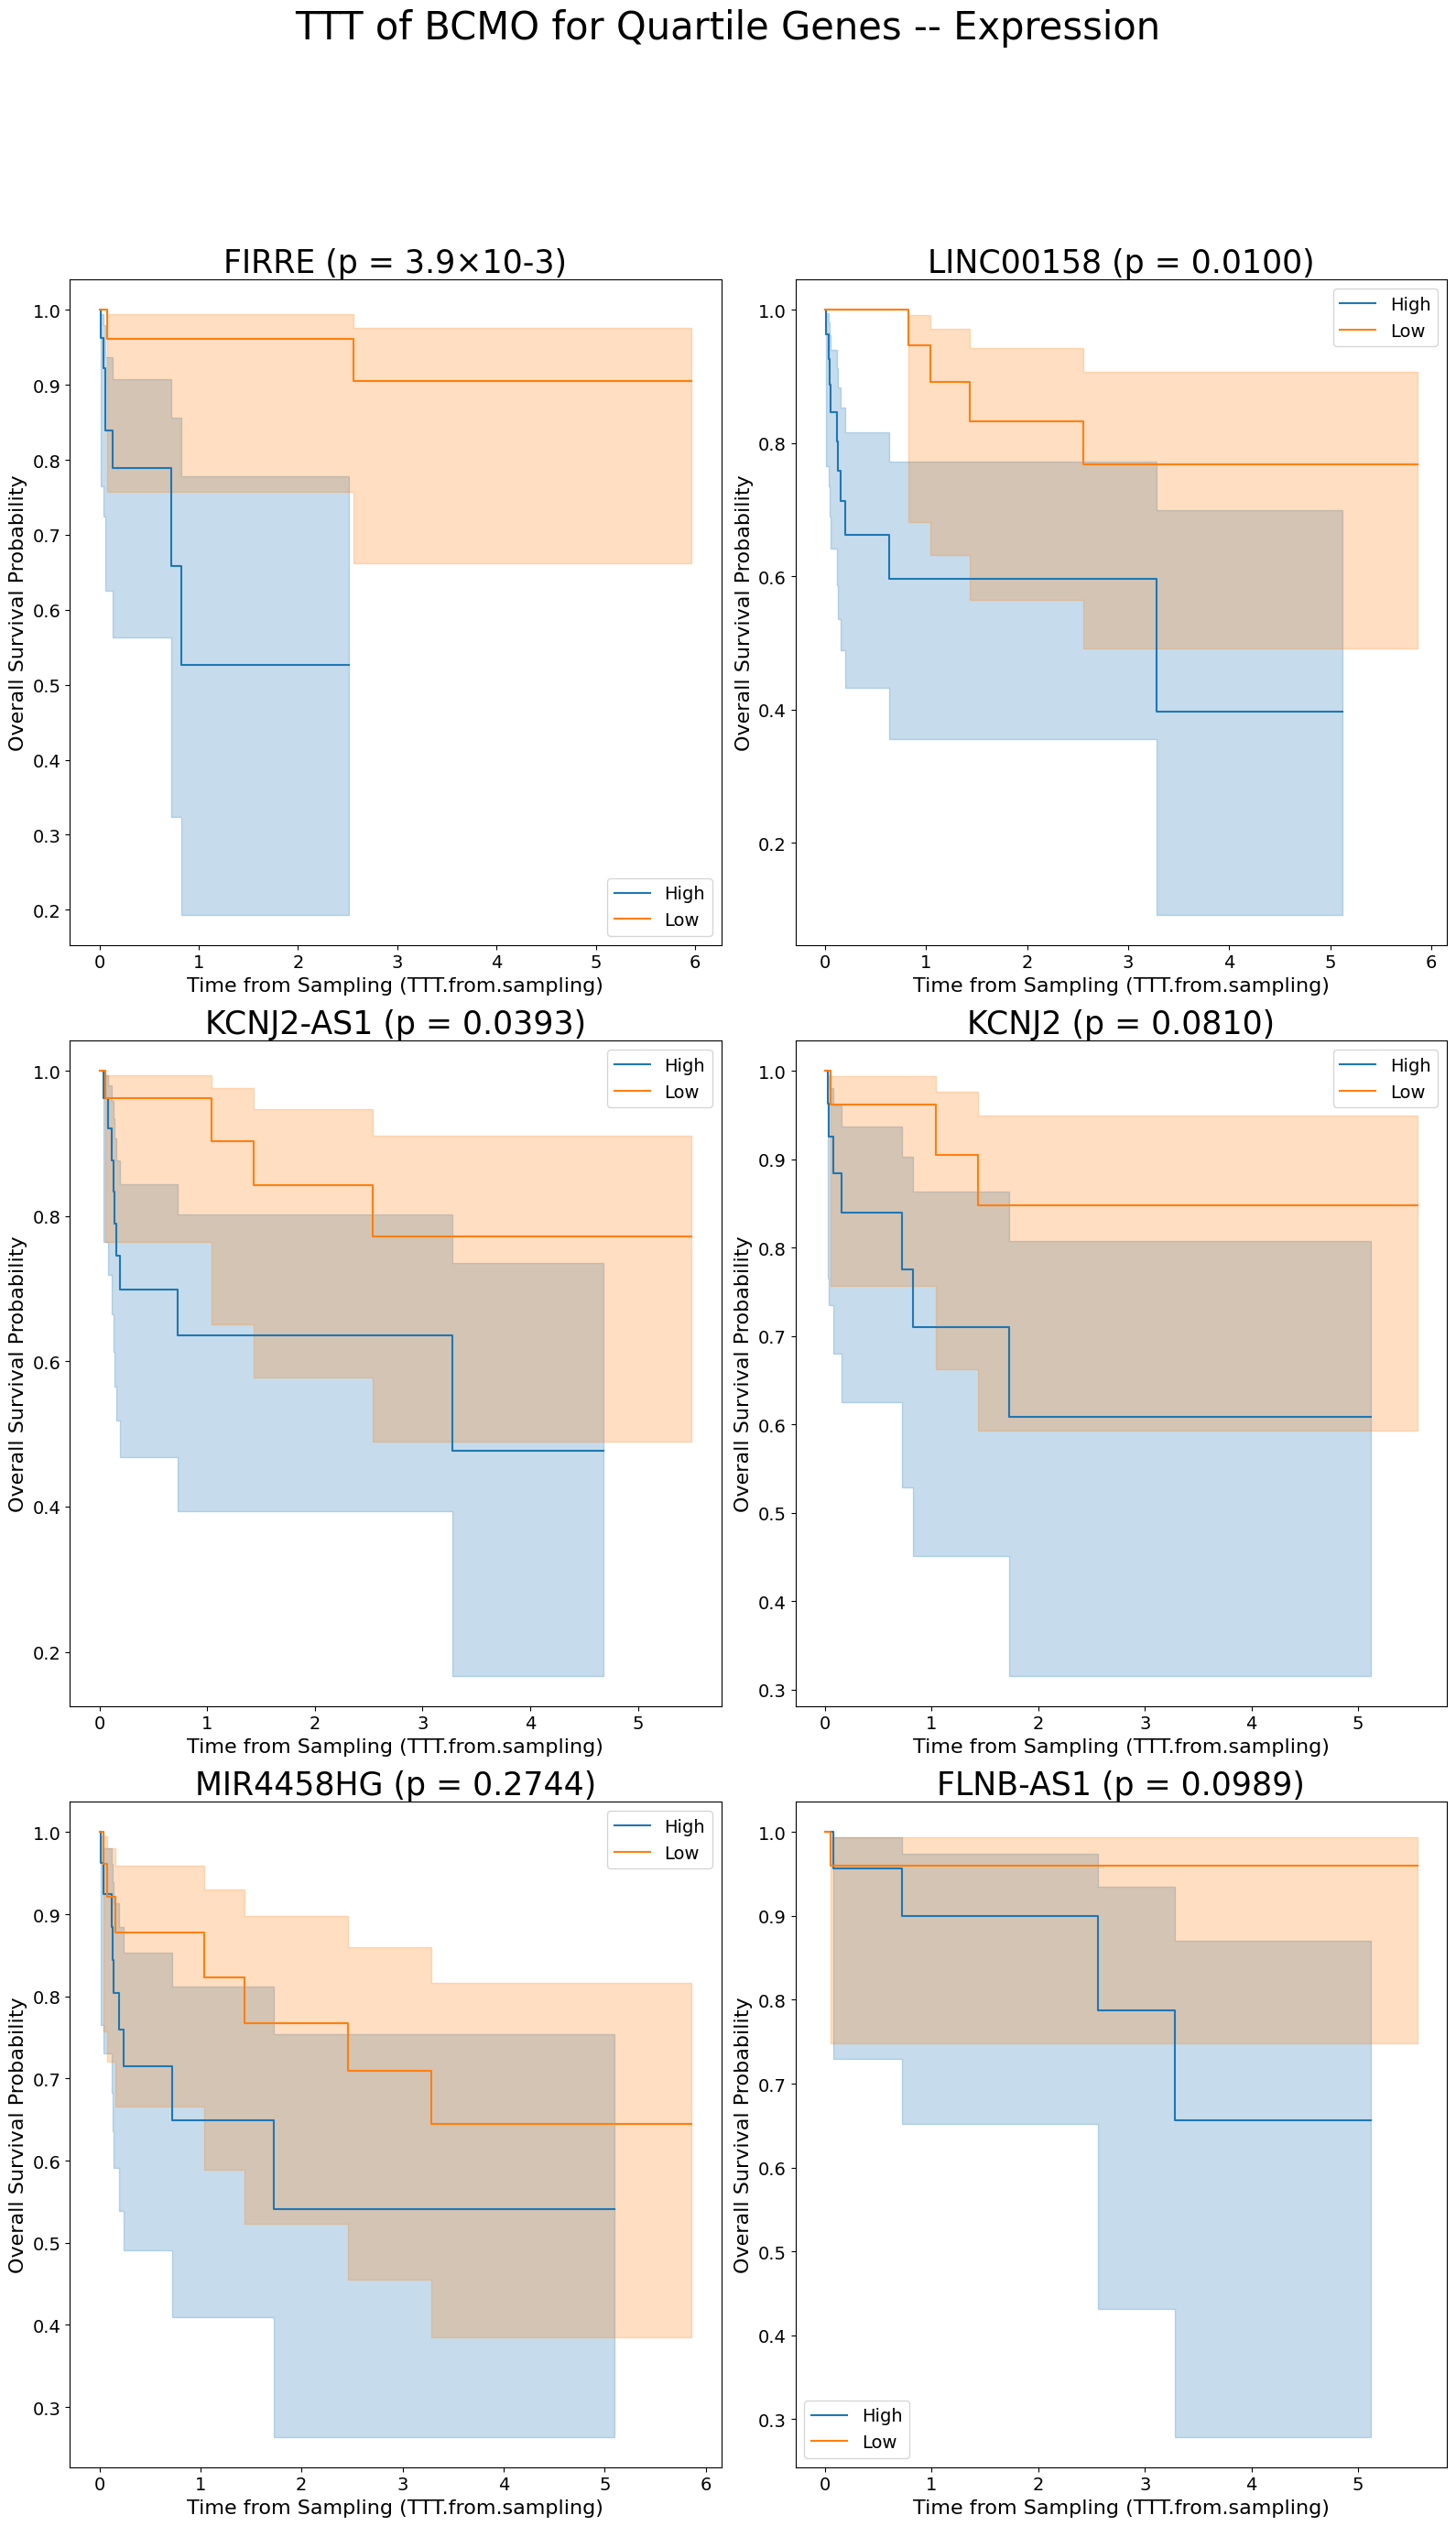

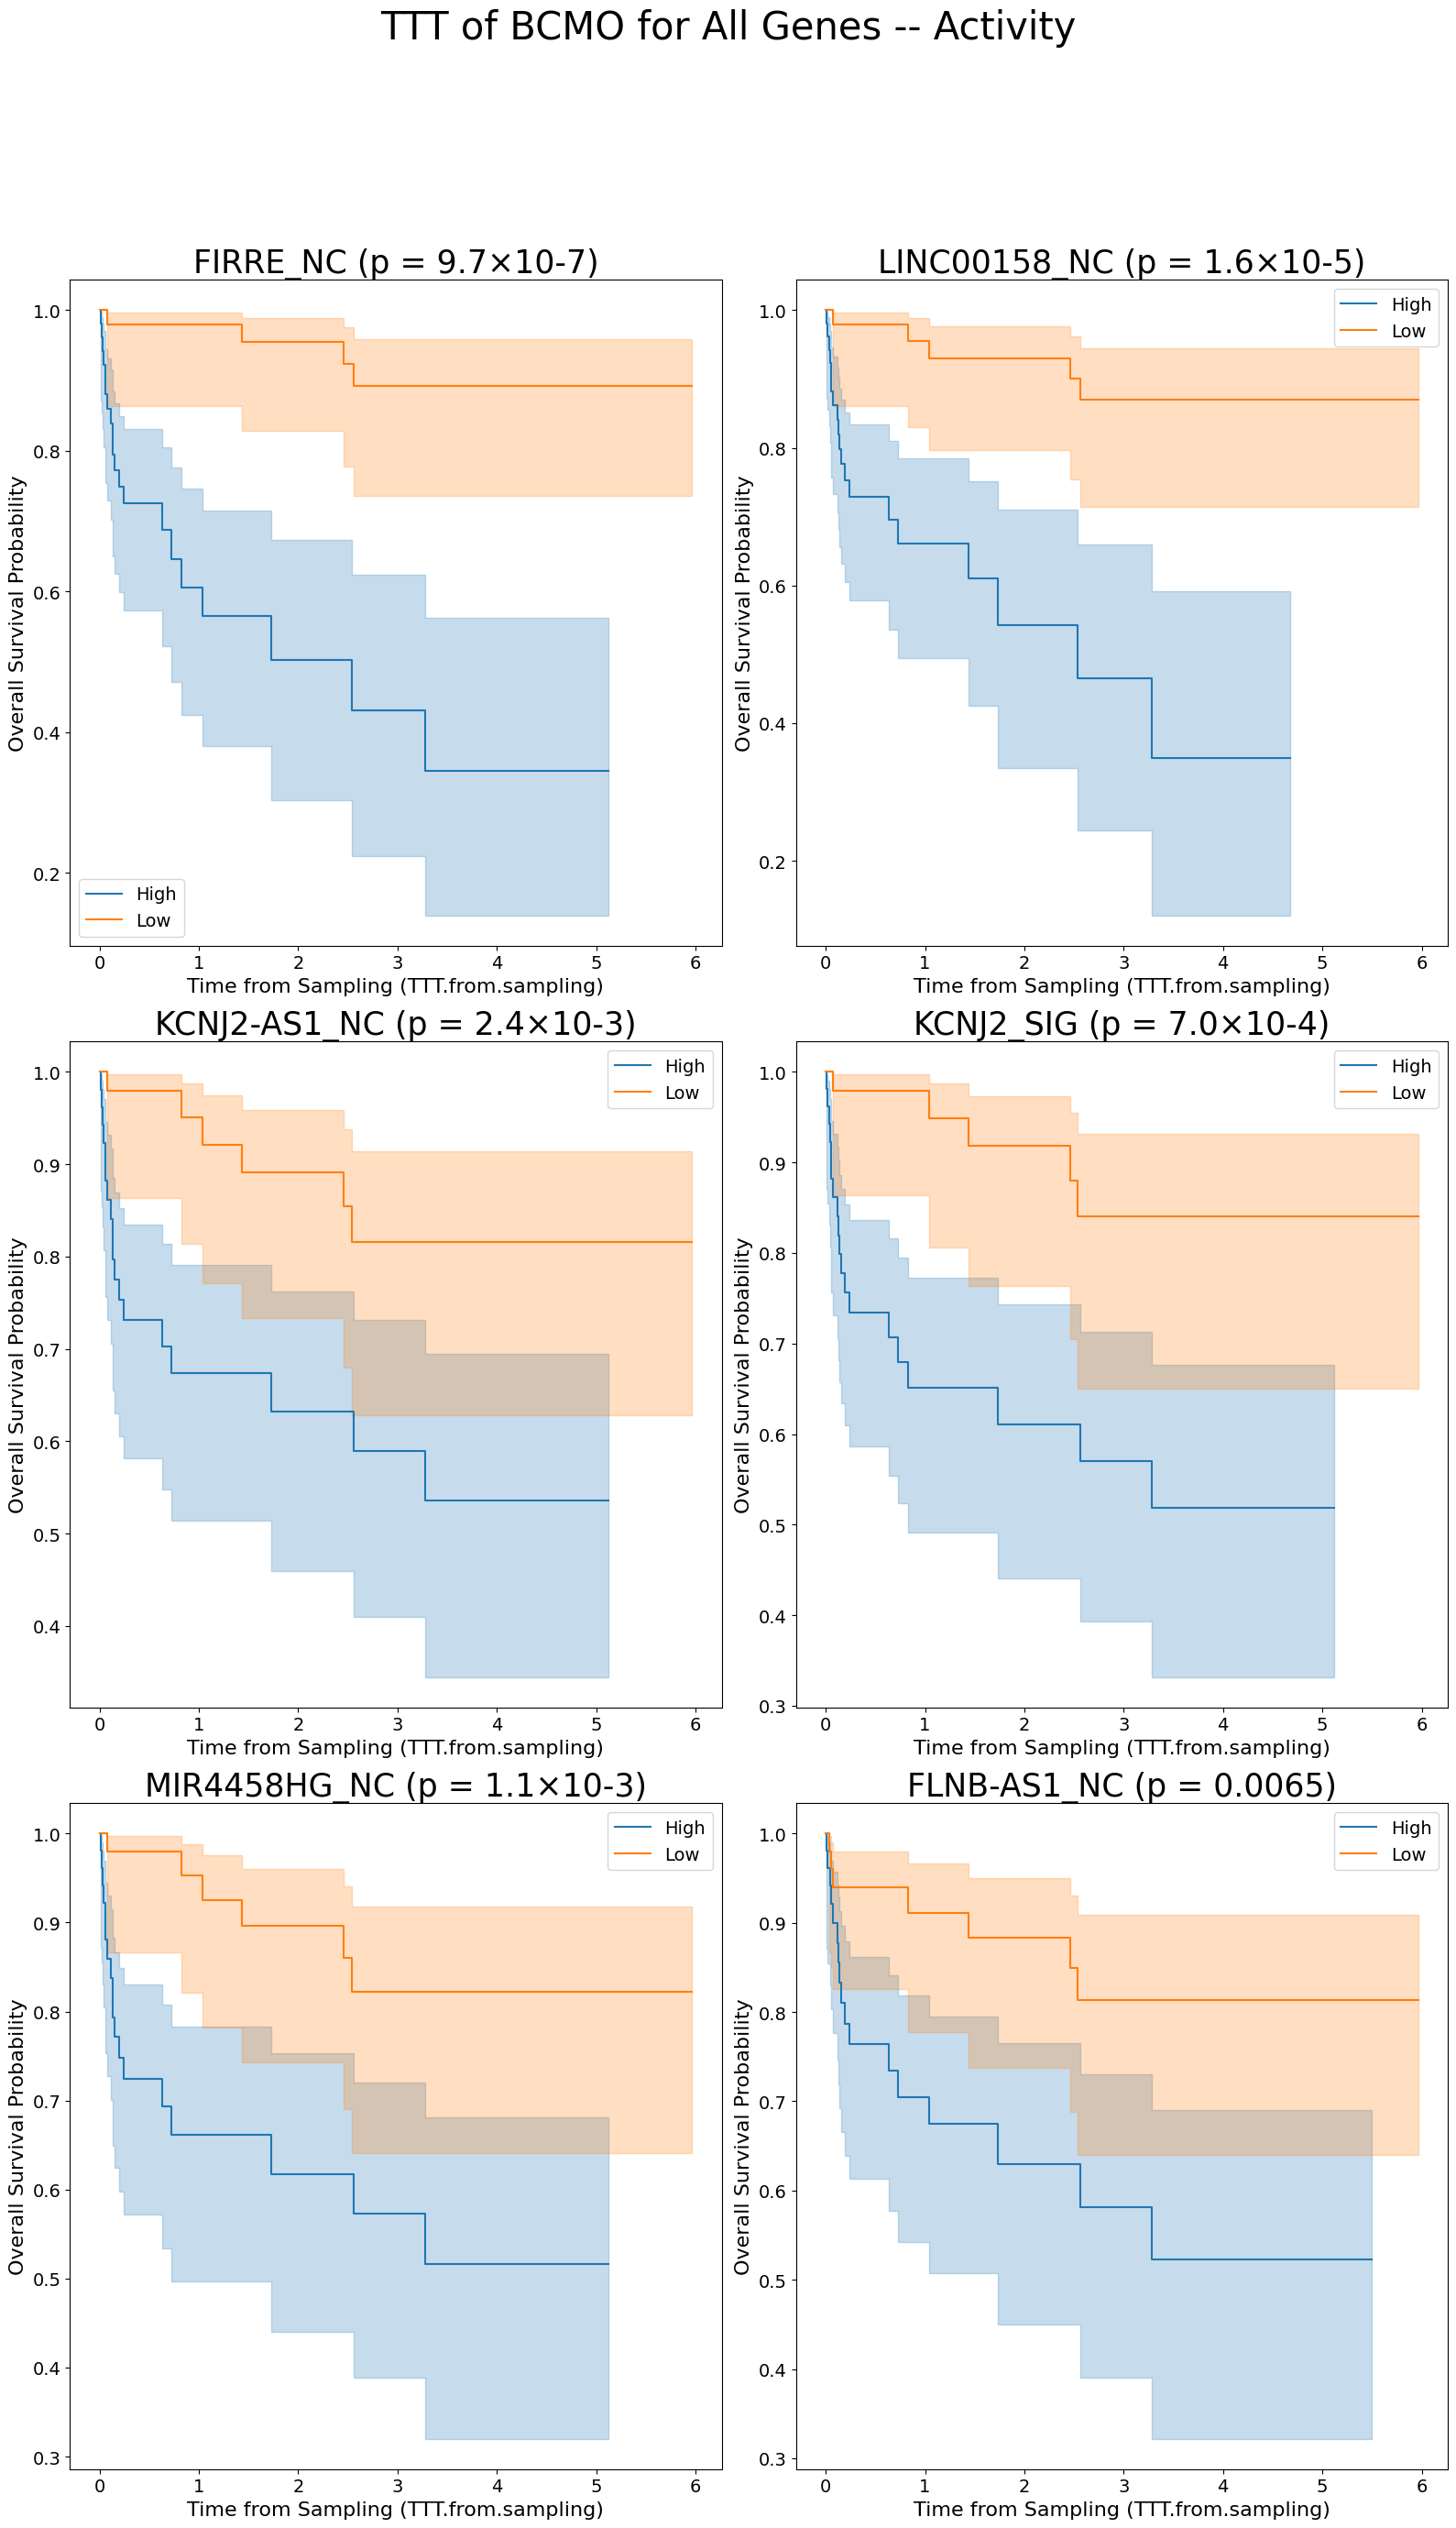

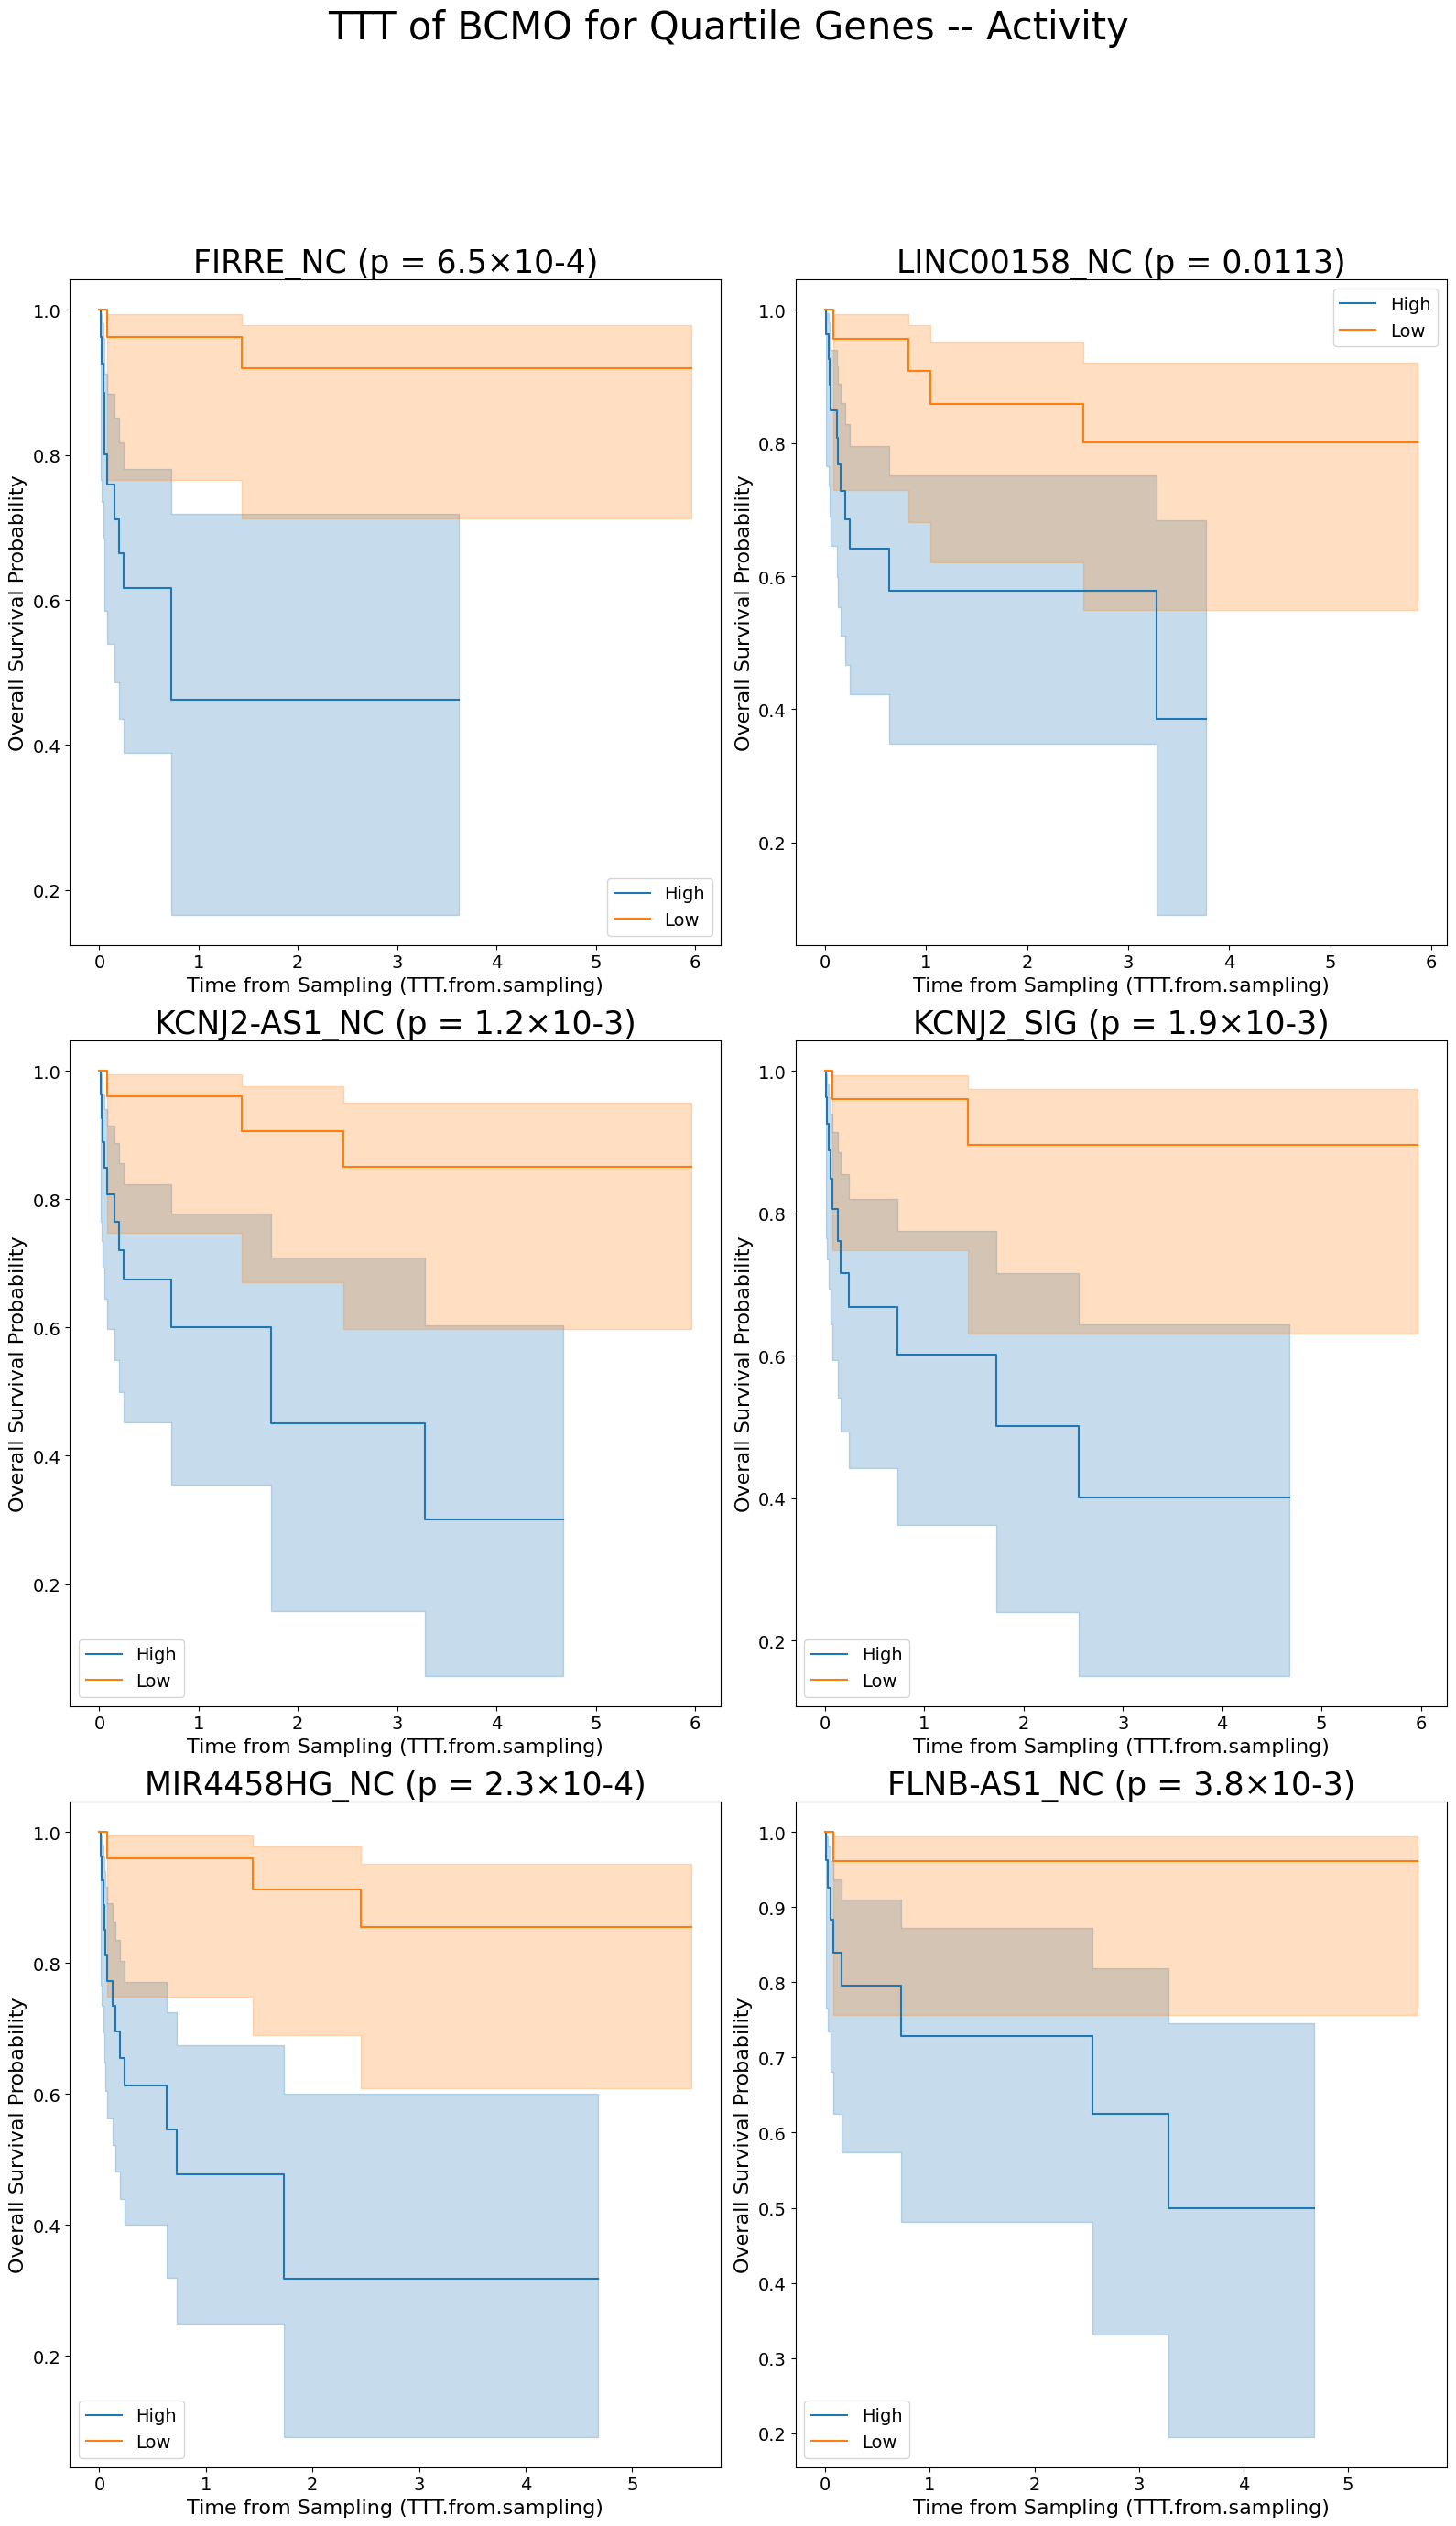

In [25]:
# Expression BCMO with all genes

genes = ["FIRRE", "LINC00158", "KCNJ2-AS1", "KCNJ2", "MIR4458HG", "FLNB-AS1"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/count_matrix.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_TTT_all_genes_BCMO_expression.png",
    split_method="median",
    fig_title="TTT of BCMO for All Genes -- Expression",
    time_col="TTT.from.sampling"
)

# Expression BCMO with quartile genes

genes = ["FIRRE", "LINC00158", "KCNJ2-AS1", "KCNJ2", "MIR4458HG", "FLNB-AS1"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/count_matrix.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_TTT_quartile_genes_BCMO_expression.png",
    split_method="quartile",
    fig_title="TTT of BCMO for Quartile Genes -- Expression",
    time_col="TTT.from.sampling"
)

# Activity BCMO with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "KCNJ2_SIG", "MIR4458HG_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_TTT_all_genes_BCMO_activity.png",
    split_method="median",
    fig_title="TTT of BCMO for All Genes -- Activity",
    time_col="TTT.from.sampling"
)

# Activity BCMO with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "KCNJ2_SIG", "MIR4458HG_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../data/BCMO/clinical_info.csv",
    expr_file="../../data/BCMO/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_TTT_quartile_genes_BCMO_activity.png",
    split_method="quartile",
    fig_title="TTT of BCMO for Quartile Genes -- Activity",
    time_col="TTT.from.sampling"
)


In [14]:
## ICGC ##

In [32]:
def kaplan_meier_plots(
    clinical_file,
    expr_file,
    genes,
    output_file,
    split_method="median",
    fig_title=None,
    time_col="OS.from.sampling"
):
    """
    Generate Kaplan-Meier survival plots for a list of genes.

    Parameters:
    - clinical_file: path to clinical CSV (must have Sample_ID and Status)
    - expr_file: path to expression/activity CSV (genes x samples)
    - genes: list of gene names to analyze
    - output_file: path to save the figure
    - split_method: "median" or "quartile"
    - fig_title: string for the figure-wide title (optional)
    - time_col: name of the time column in clinical data
    """
    # 1. Load clinical data
    clinical = pd.read_csv(clinical_file)
    clinical = clinical.dropna(subset=['donor_vital_status', 'donor_survival_time'])
    clinical['donor_vital_status'] = clinical['donor_vital_status'].map({'alive': 0, 'deceased': 1})
    clinical = clinical.rename(columns={"donor_vital_status": "Status"})
    
    # 2. Load expression/activity matrix
    expr = pd.read_csv(expr_file, index_col=0)
    
    # 3. Determine subplot grid size dynamically
    n_genes = len(genes)
    n_cols = 2
    n_rows = math.ceil(n_genes / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9 * n_rows))
    axes = axes.flatten()
    
    # 4. Figure-wide title
    if fig_title is None:
        title_map = {
            "median": "Survival Analysis of ICGC for ALL Genes -- ACTIVITY",
            "quartile": "Survival Analysis of ICGC for Quartile Genes (Activity)"
        }
        fig_title = title_map.get(split_method, "Survival Analysis")
    fig.suptitle(fig_title, fontsize=30, y=1.02)
    
    # 5. Loop through genes
    for i, gene in enumerate(genes):
        ax = axes[i]
        
        if gene not in expr.index:
            ax.text(0.5, 0.5, f"{gene} not found", ha='center', va='center', fontsize=14)
            ax.axis('off')
            continue
        
        # Extract gene activity
        gene_activity = expr.loc[gene].rename("Activity")
        
        # Merge with clinical data
        df = clinical.merge(gene_activity, left_on="Samples", right_index=True)
        
        # Define High/Low groups
        if split_method == "median":
            df[f"{gene}_group"] = (df["Activity"] > df["Activity"].median()).map({True: "High", False: "Low"})
            df_to_use = df
        elif split_method == "quartile":
            q_low = df["Activity"].quantile(0.25)
            q_high = df["Activity"].quantile(0.75)
            df_to_use = df[(df["Activity"] <= q_low) | (df["Activity"] >= q_high)].copy()
            df_to_use[f"{gene}_group"] = df_to_use["Activity"].apply(lambda x: "High" if x >= q_high else "Low")
        else:
            raise ValueError("split_method must be 'median' or 'quartile'")
        
        # Kaplan–Meier plot
        kmf = KaplanMeierFitter()
        for group, grouped_df in df_to_use.groupby(f"{gene}_group"):
            kmf.fit(grouped_df[time_col], grouped_df["Status"], label=group)
            kmf.plot_survival_function(ax=ax, ci_show=True)
        
        # Log-rank test
        high = df_to_use[df_to_use[f"{gene}_group"] == "High"]
        low = df_to_use[df_to_use[f"{gene}_group"] == "Low"]
        results = logrank_test(
            high[time_col], low[time_col],
            event_observed_A=high["Status"], event_observed_B=low["Status"]
        )
        pval = results.p_value

        # Format p-value
        if pval >= 0.005:
            pval_str = f"{pval:.4f}"
        else:
            pval_str = f"{pval:.1e}".replace("e-0", "e-").replace("e", "×10")

        # Set subplot title and labels
        ax.set_title(f"{gene} (p = {pval_str})", fontsize=25)
        ax.set_xlabel(f"Time from Sampling ({time_col})", fontsize=16)
        ax.set_ylabel("Overall Survival Probability", fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        ax.legend(fontsize=14)
    
    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()


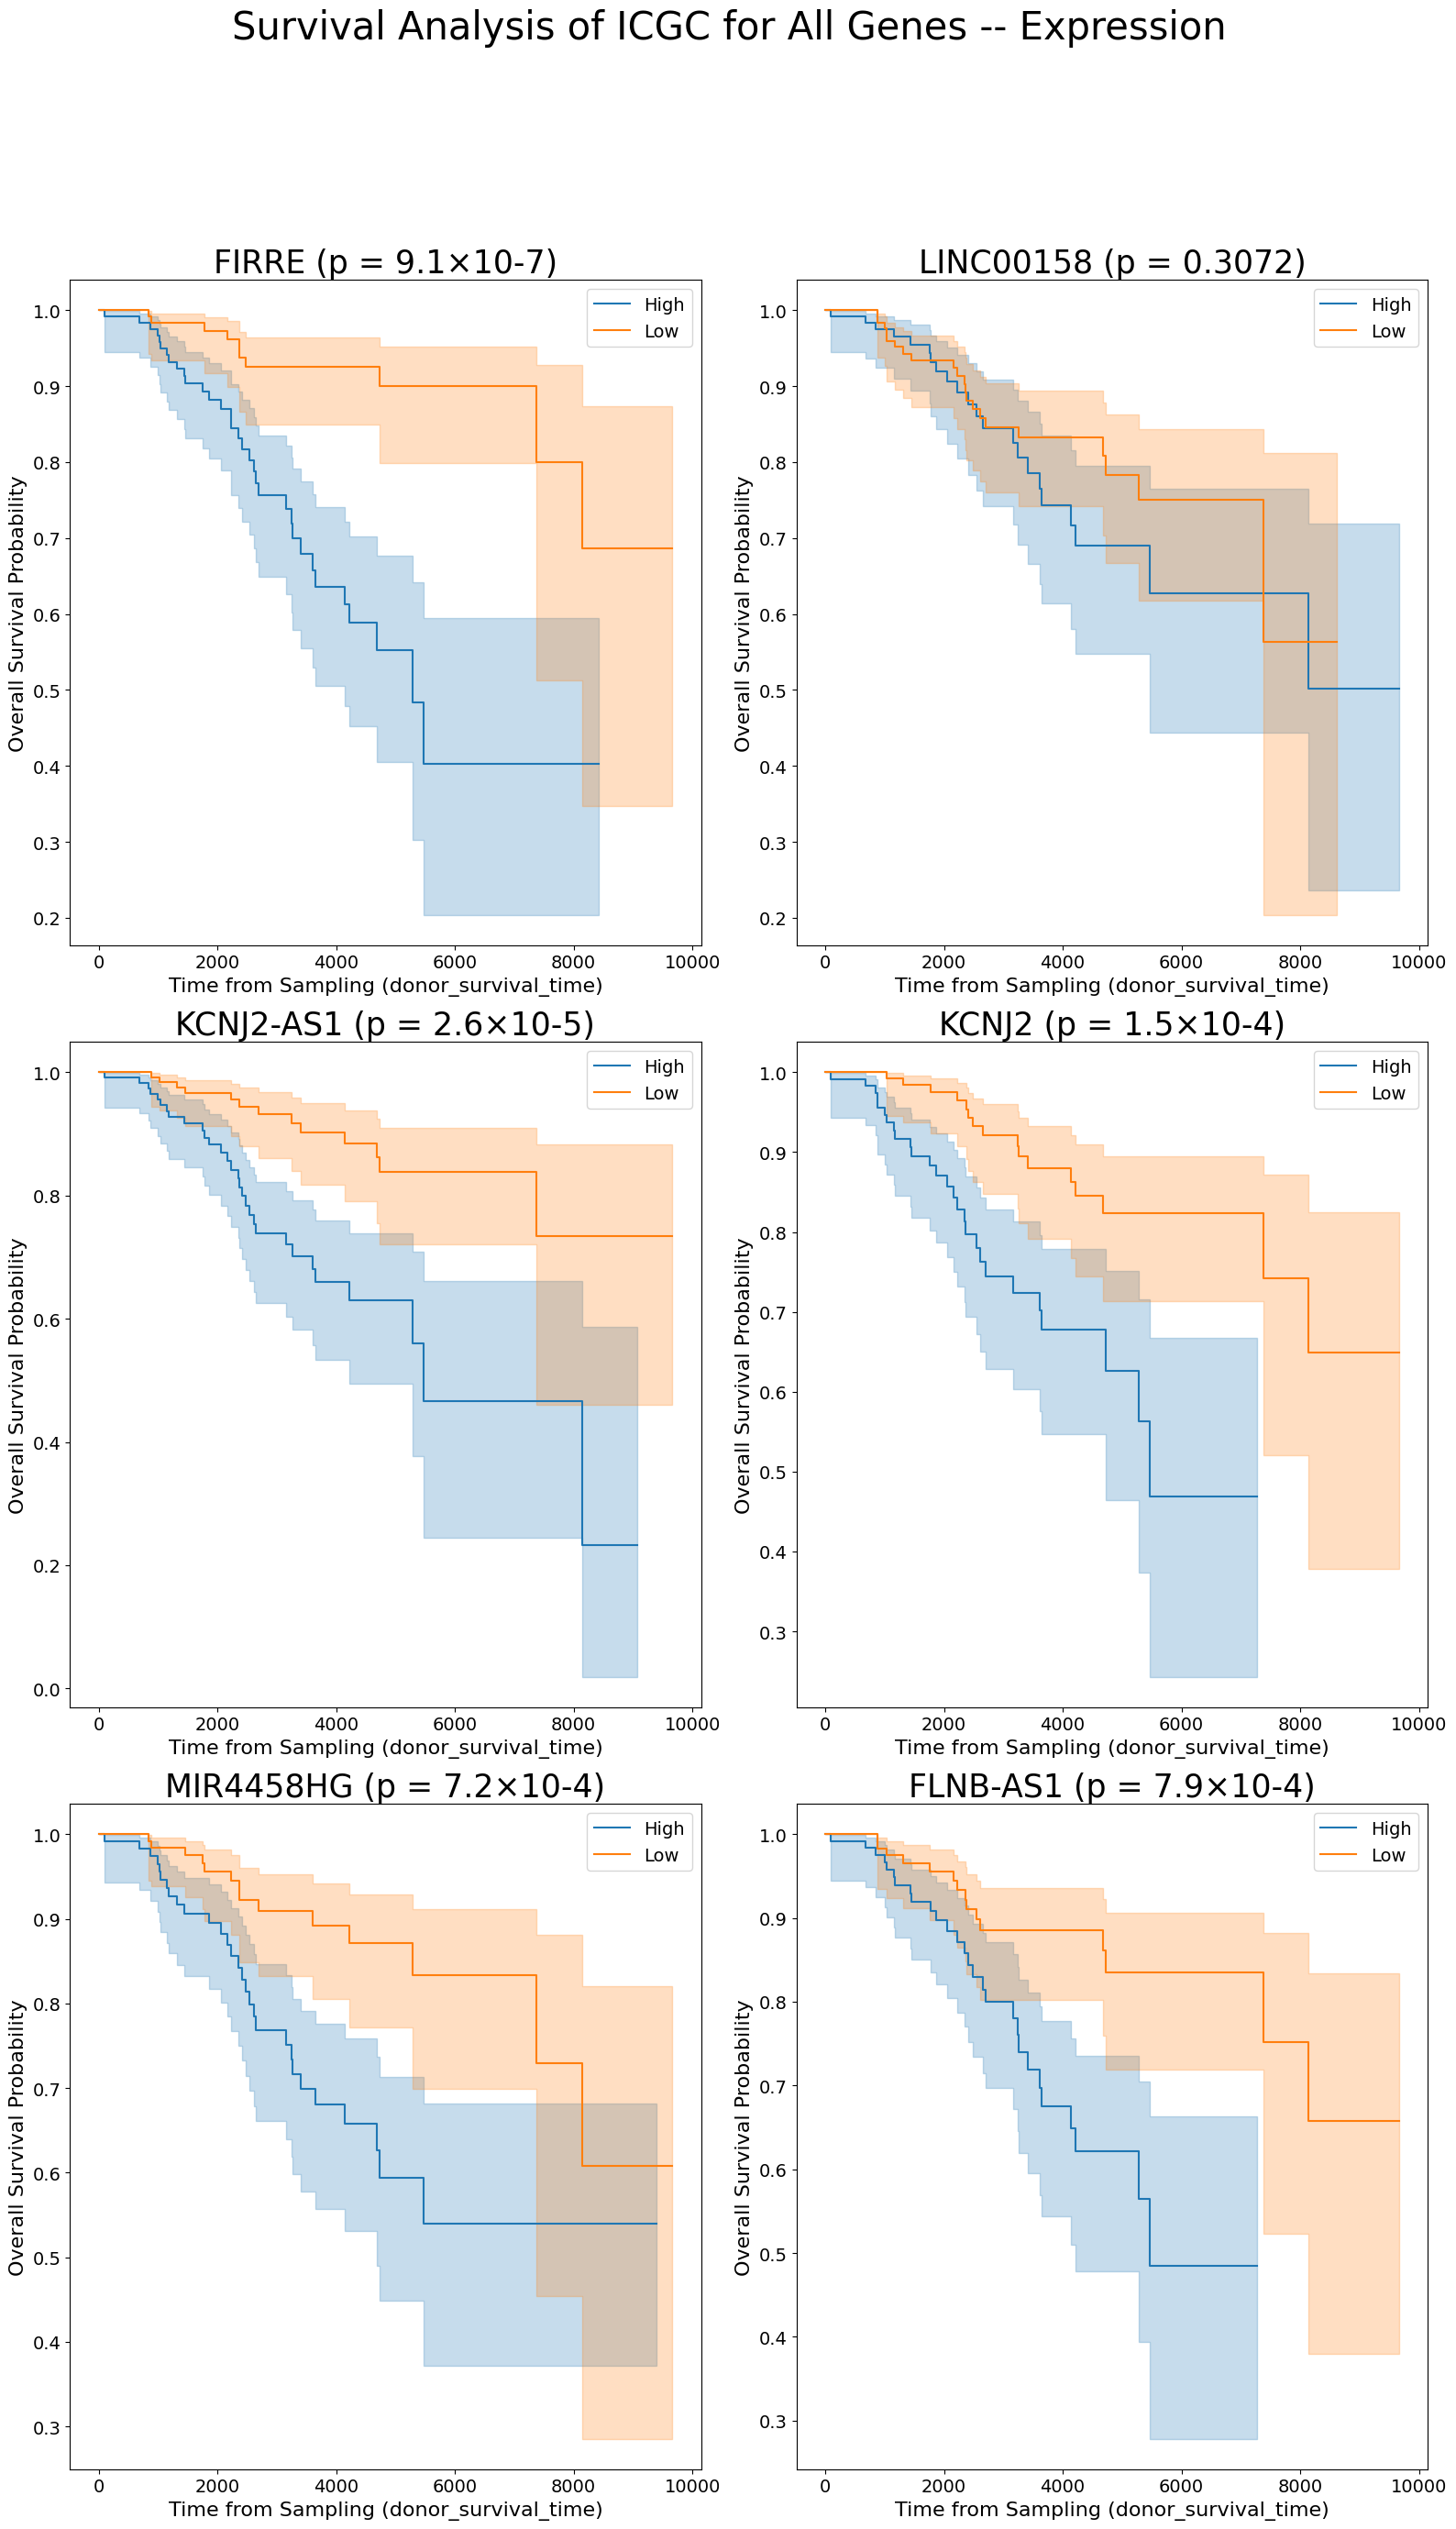

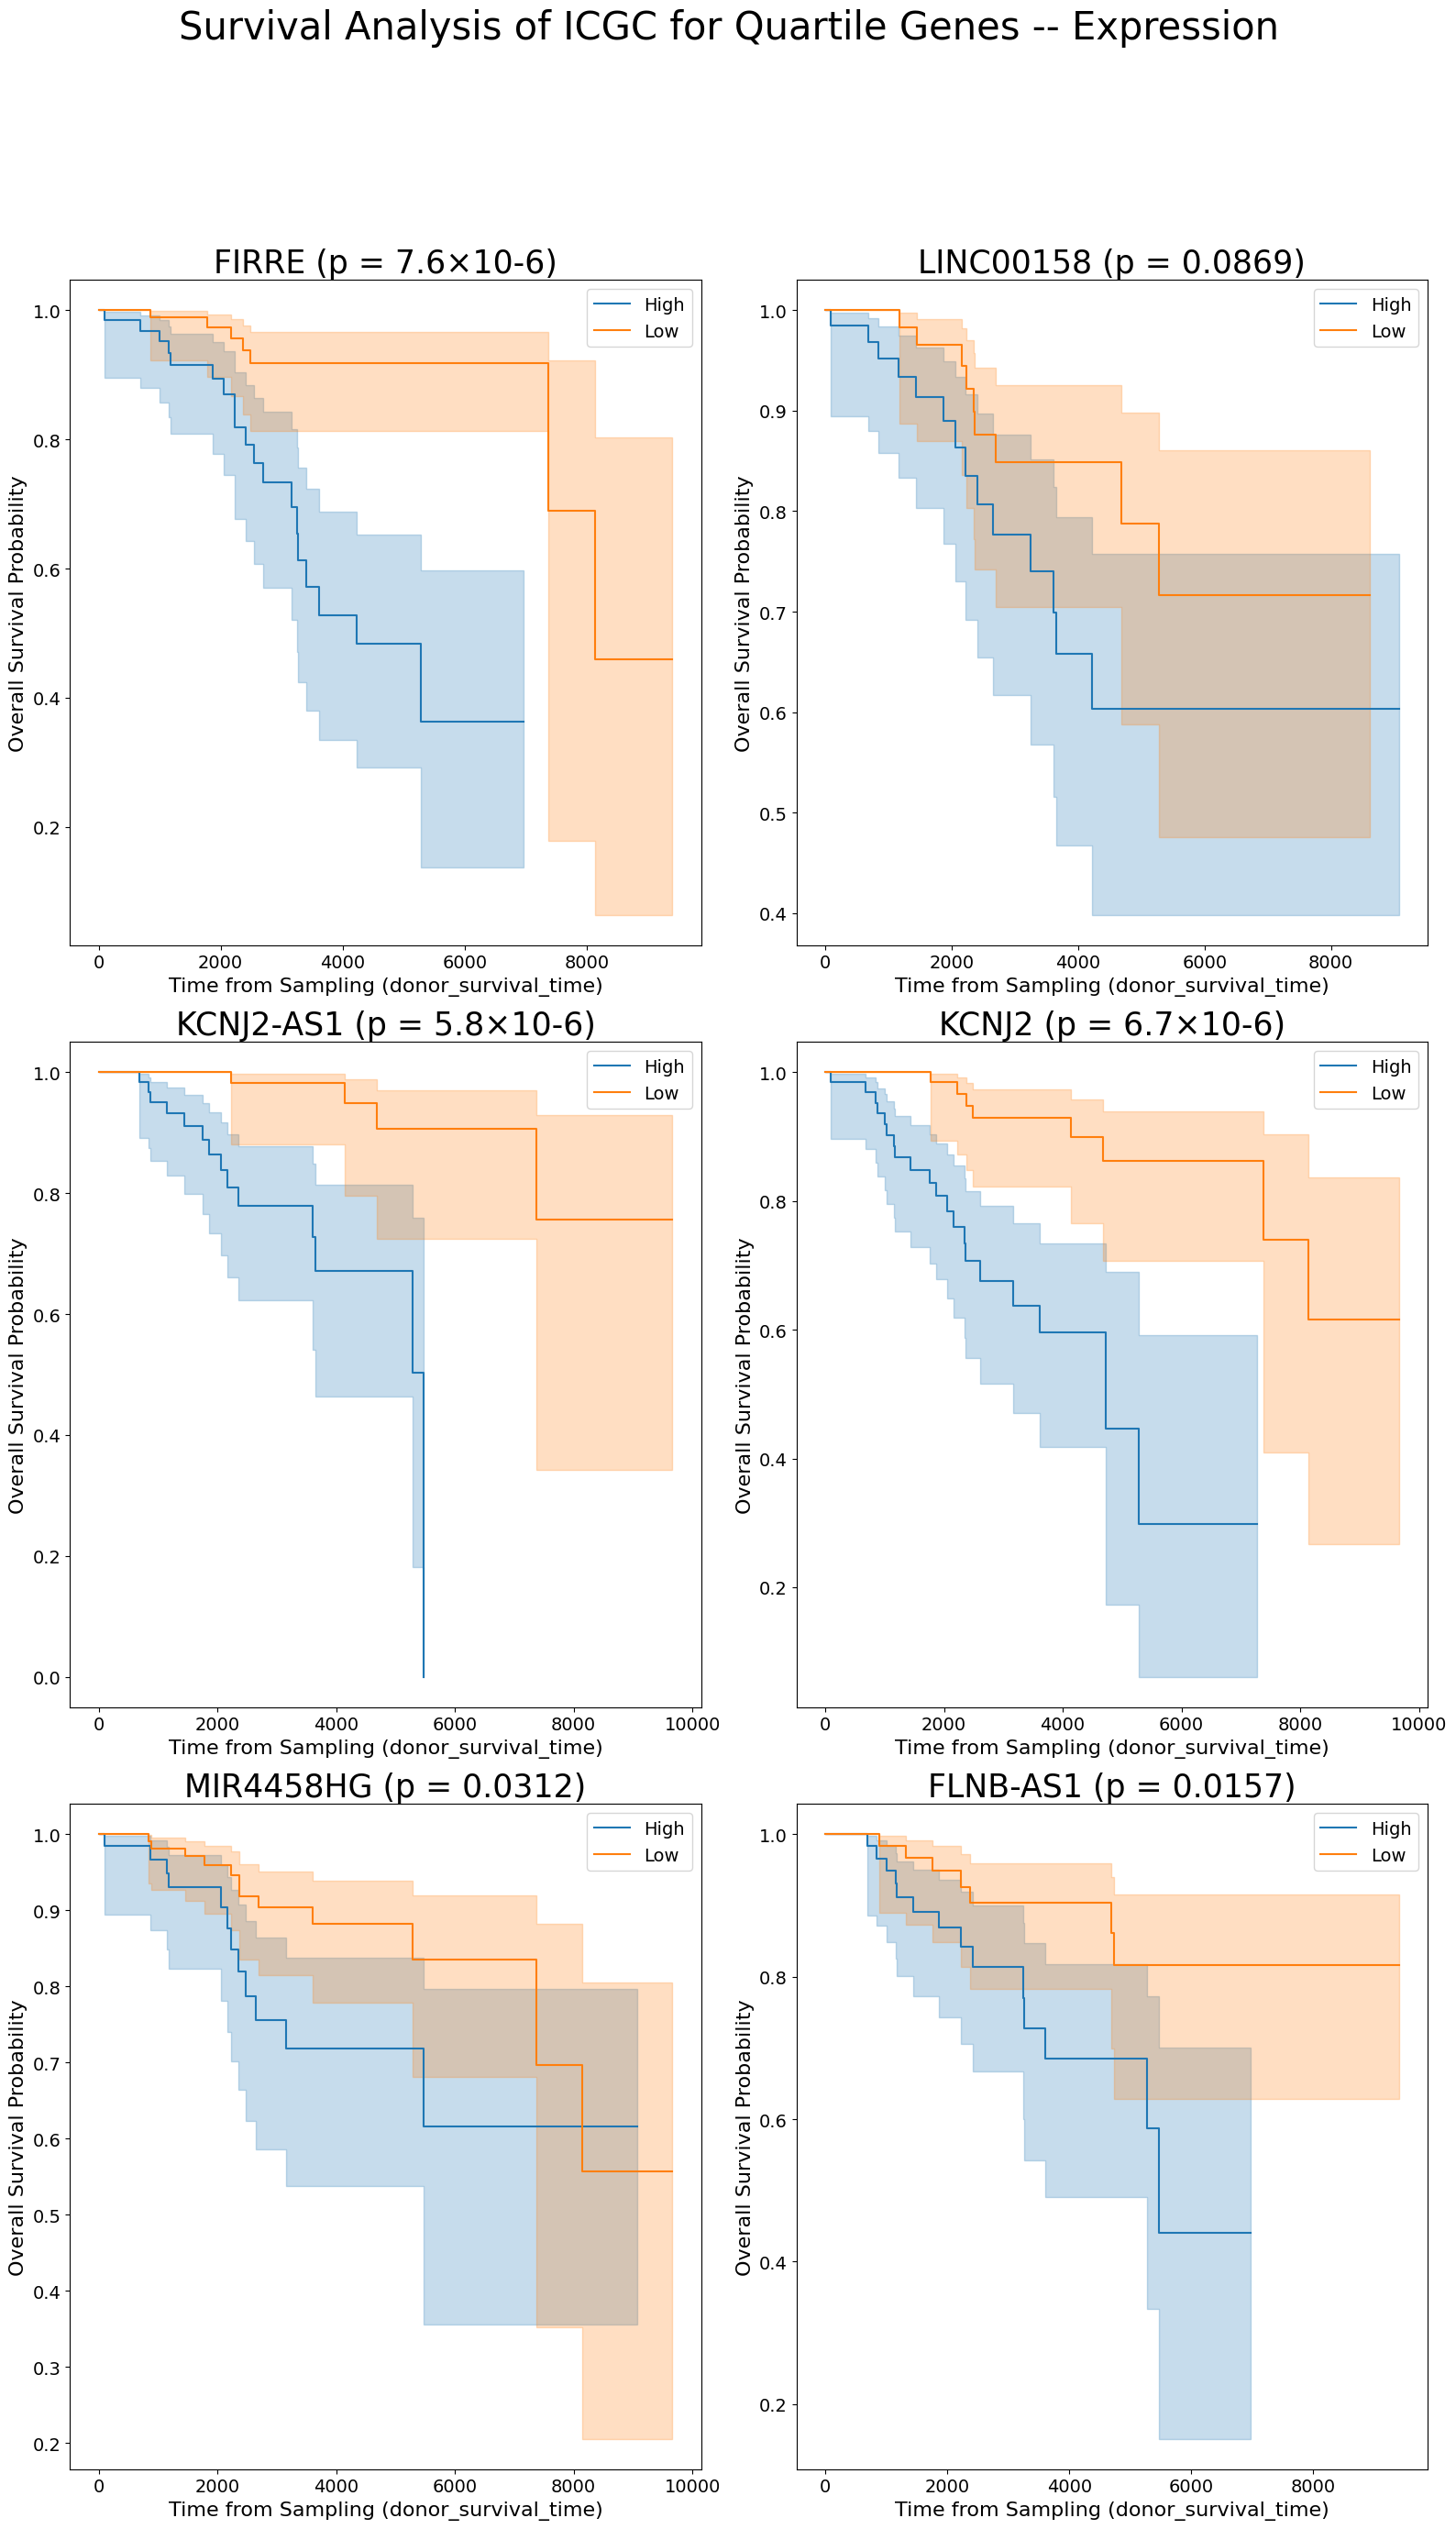

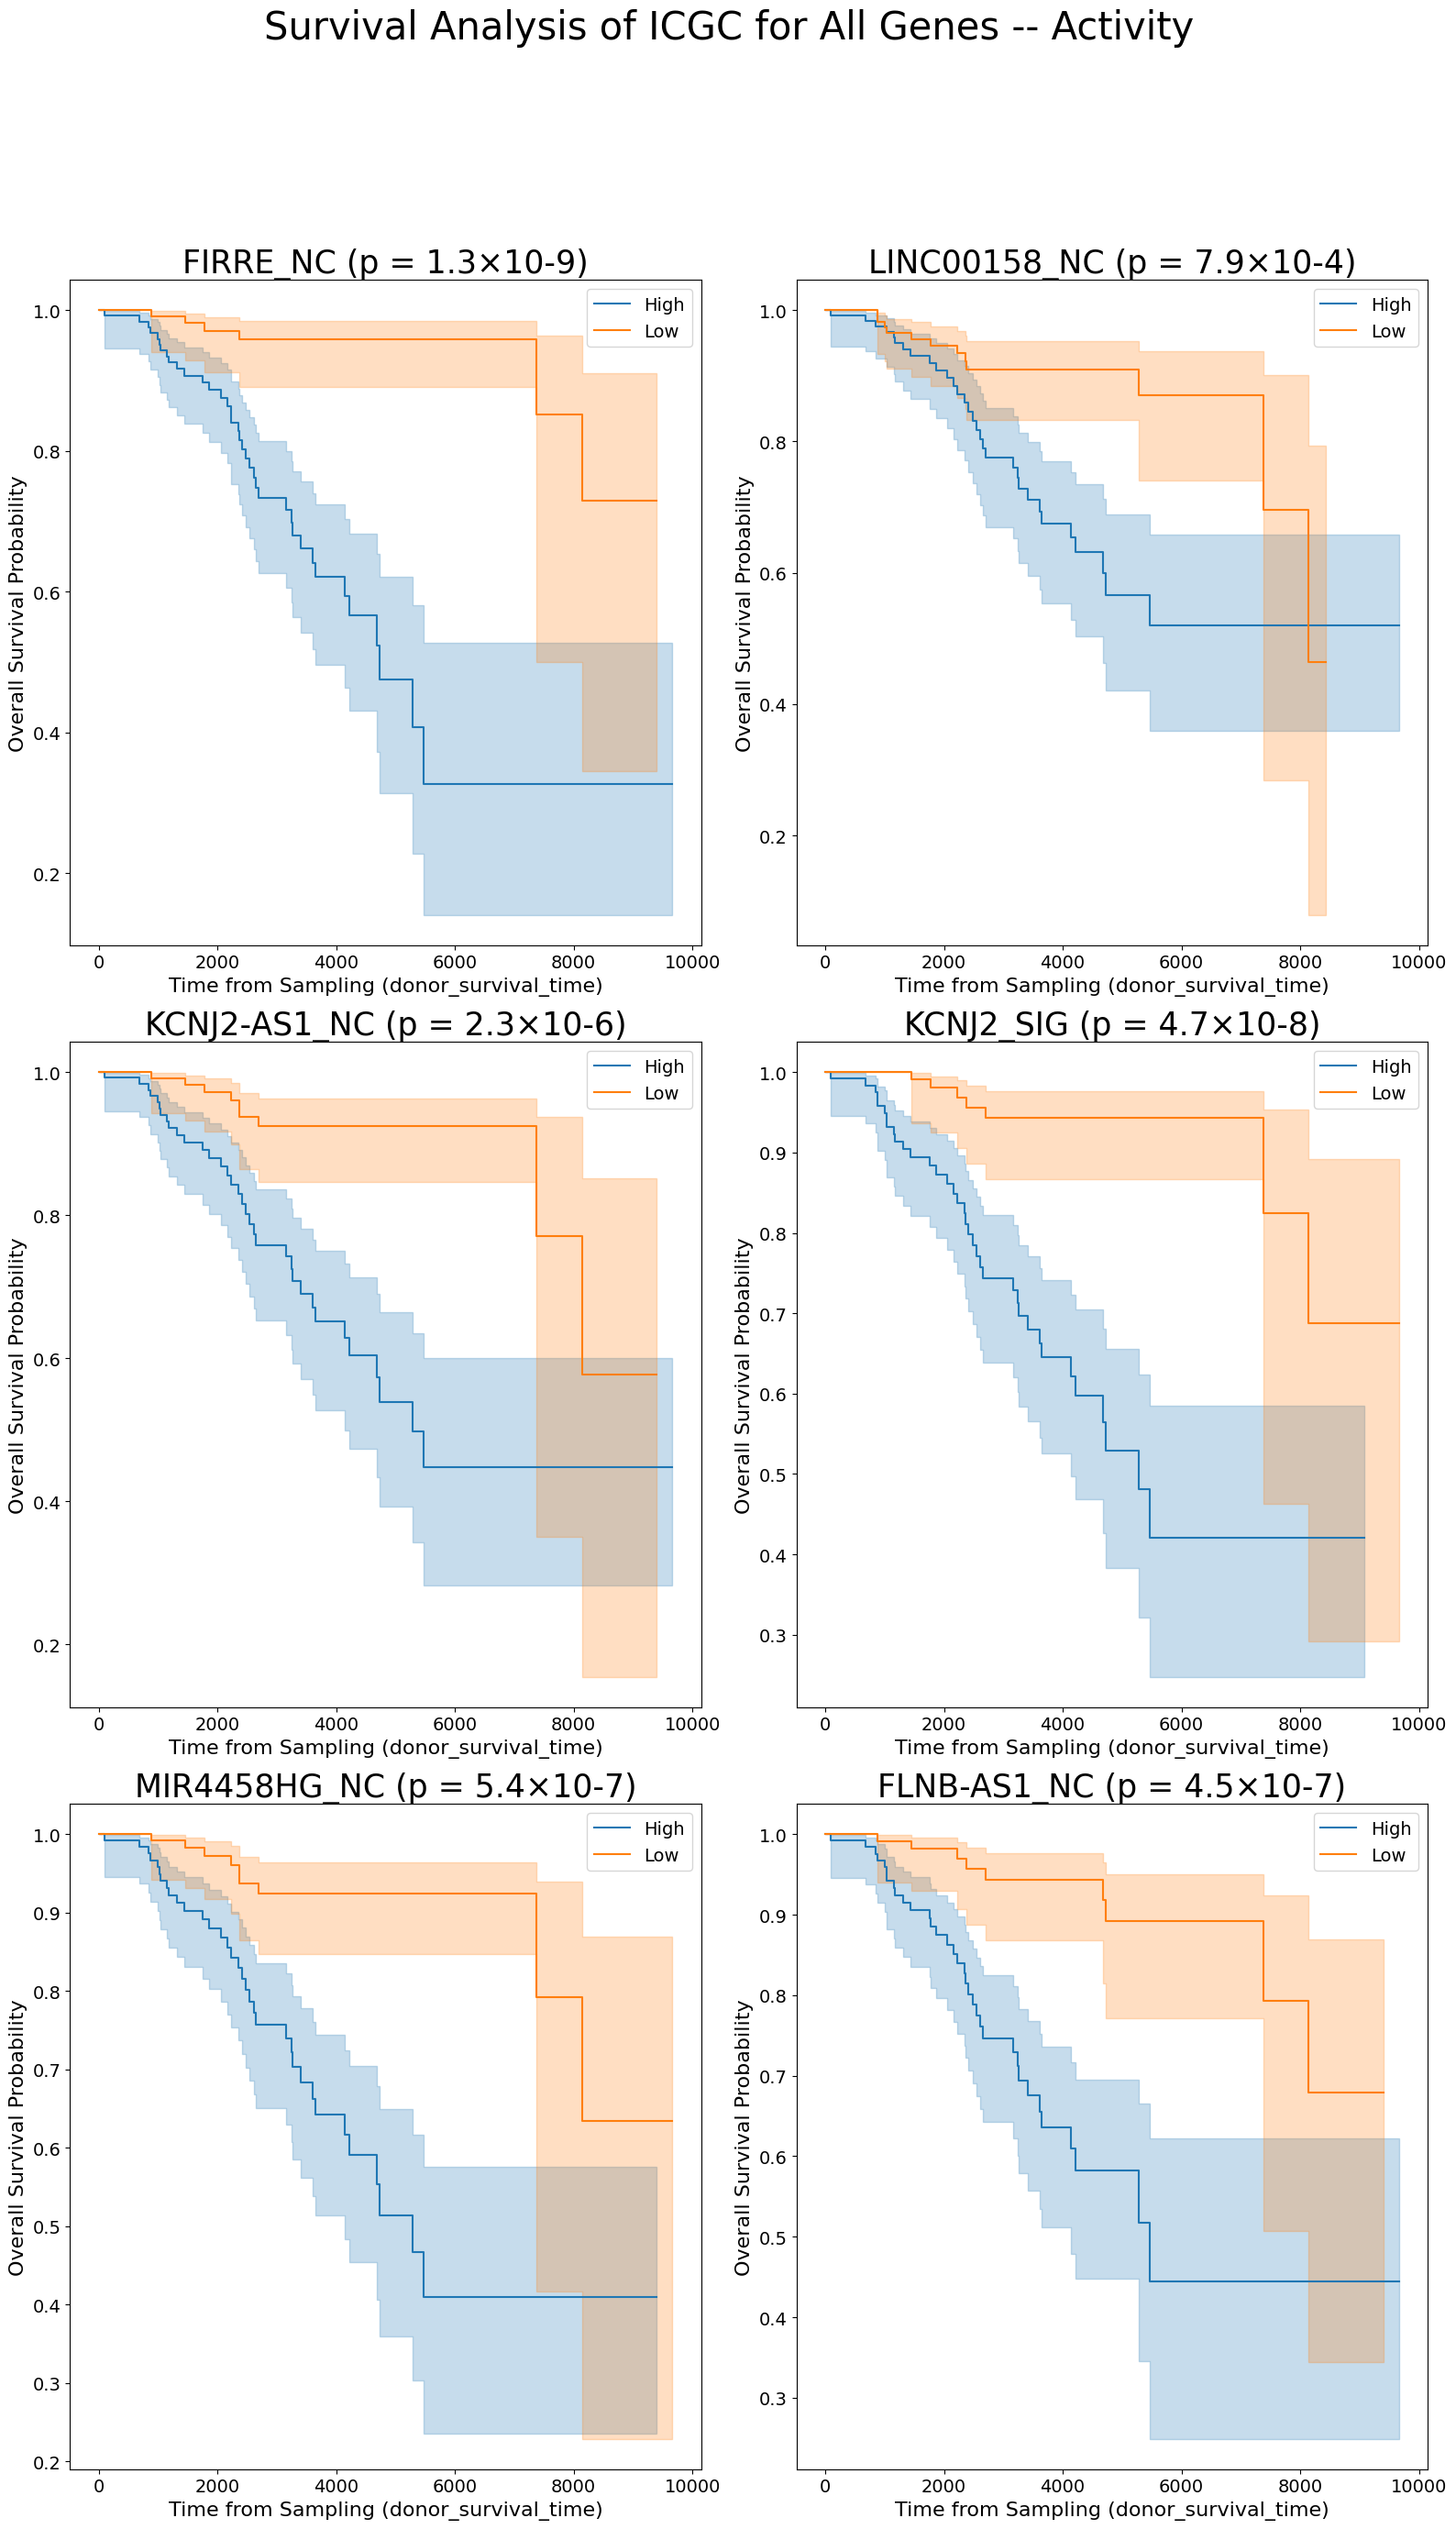

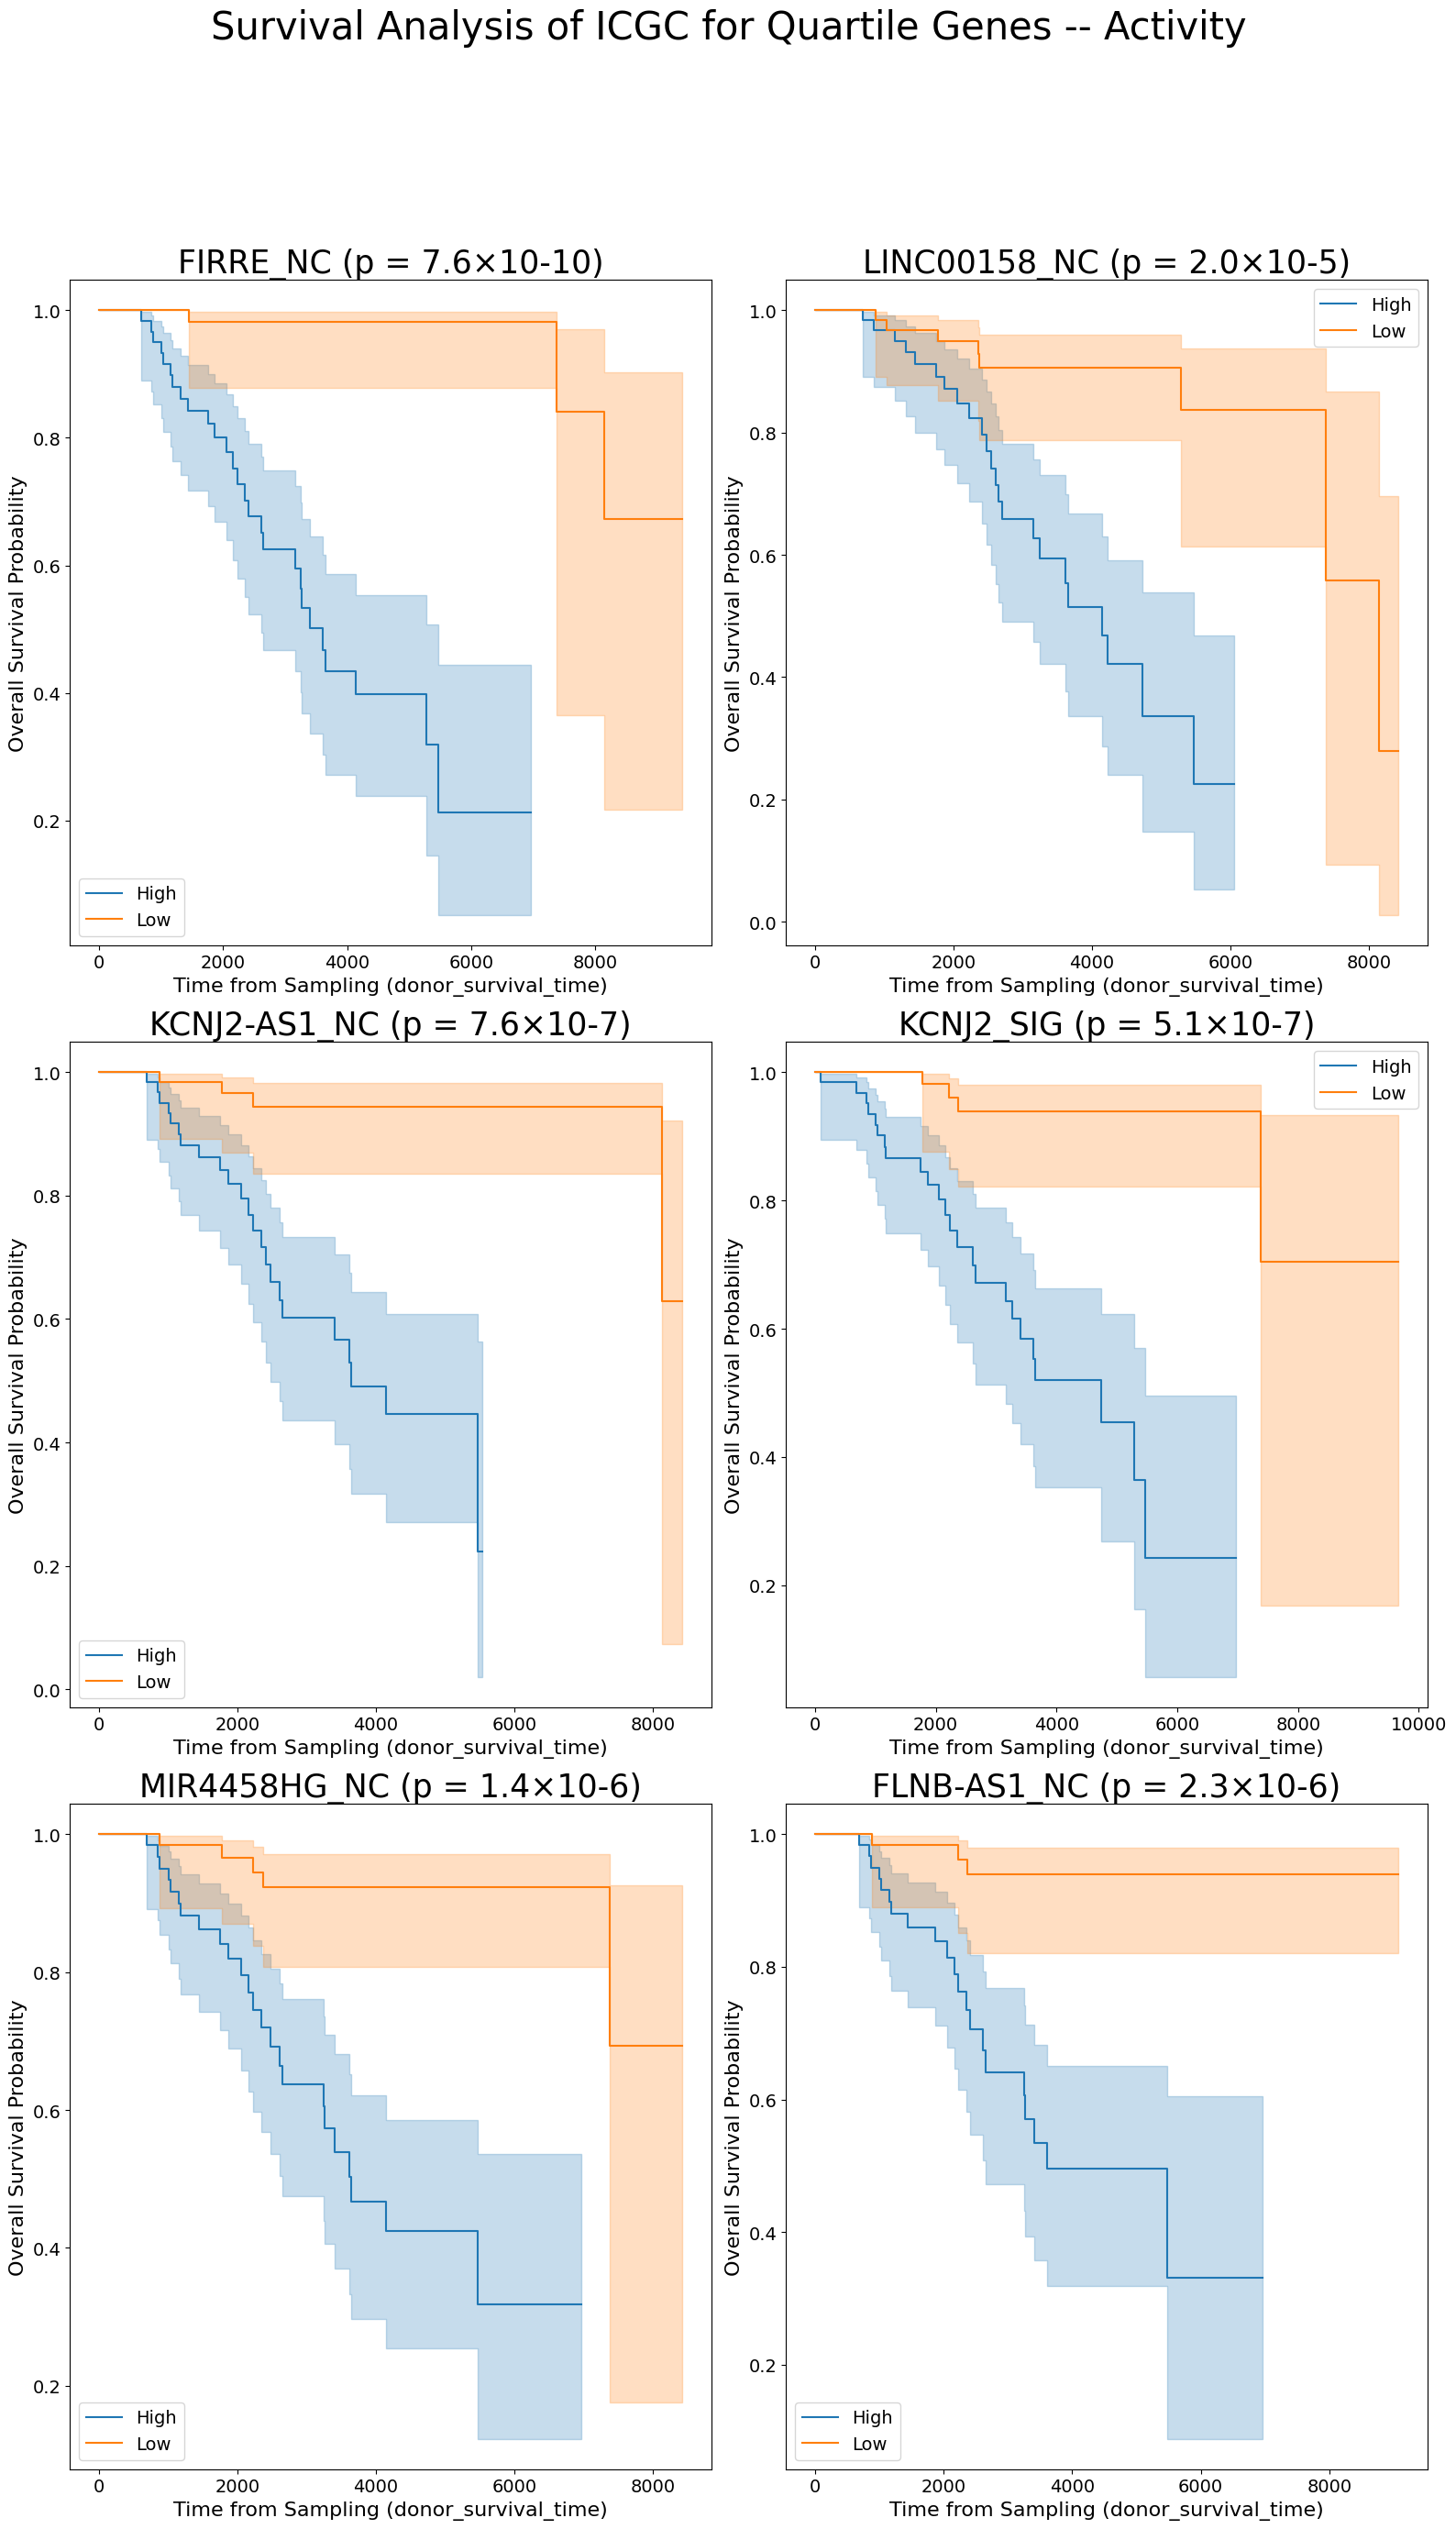

In [33]:
# Expression ICGC with all genes

genes = ["FIRRE", "LINC00158", "KCNJ2-AS1", "KCNJ2", "MIR4458HG", "FLNB-AS1"]

kaplan_meier_plots(
    clinical_file="../../data/ICGC/clinical_info.csv",
    expr_file="../../data/ICGC/count_matrix.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_all_genes_ICGC_expression.png",
    split_method="median",
    fig_title="Survival Analysis of ICGC for All Genes -- Expression",
    time_col="donor_survival_time"
)

# Expression ICGC with quartile genes

genes = ["FIRRE", "LINC00158", "KCNJ2-AS1", "KCNJ2", "MIR4458HG", "FLNB-AS1"]

kaplan_meier_plots(
    clinical_file="../../data/ICGC/clinical_info.csv",
    expr_file="../../data/ICGC/count_matrix.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_quartile_genes_ICGC_expression.png",
    split_method="quartile",
    fig_title="Survival Analysis of ICGC for Quartile Genes -- Expression",
    time_col="donor_survival_time"
)

# Activity ICGC with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "KCNJ2_SIG", "MIR4458HG_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../data/ICGC/clinical_info.csv",
    expr_file="../../data/ICGC/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_all_genes_ICGC_activity.png",
    split_method="median",
    fig_title="Survival Analysis of ICGC for All Genes -- Activity",
    time_col="donor_survival_time"
)

# Activity ICGC with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "KCNJ2_SIG", "MIR4458HG_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../data/ICGC/clinical_info.csv",
    expr_file="../../data/ICGC/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_quartile_genes_ICGC_activity.png",
    split_method="quartile",
    fig_title="Survival Analysis of ICGC for Quartile Genes -- Activity",
    time_col="donor_survival_time"
)

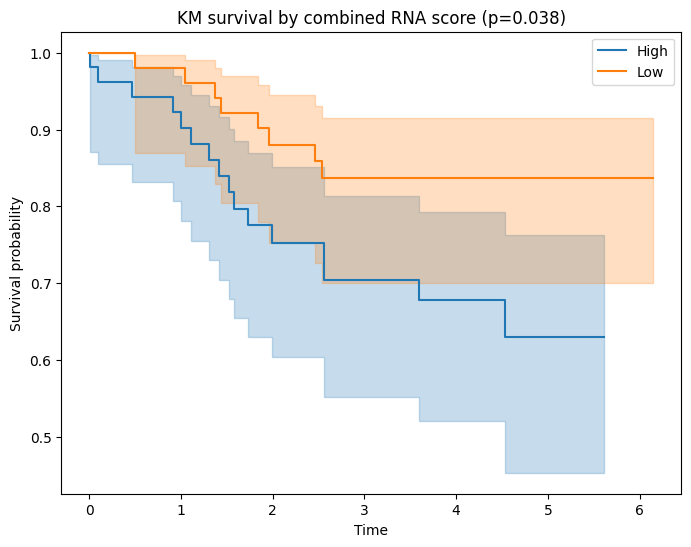

<lifelines.CoxPHFitter: fitted with 105 total observations, 81 right-censored observations>
             duration col = 'OS.from.sampling'
                event col = 'died'
      baseline estimation = breslow
   number of observations = 105
number of events observed = 24
   partial log-likelihood = -102.89
         time fit was run = 2025-09-04 11:37:13 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
FIRRE      0.00      1.00      0.00           -0.01            0.01                0.99                1.01
LINC00158  0.00      1.00      0.00            0.00            0.01                1.00                1.01
KCNJ2-AS1  0.00      1.00      0.00           -0.01            0.01                0.99                1.01
MIR4458HG  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FLNB-AS1  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to     z    p  -log2(p)
covariate                             
FIRRE        0.00  0.16 0.87      0.20
LINC00158    0.00  2.18 0.03      5.09
KCNJ2-AS1    0.00  0.59 0.55      0.85
MIR4458HG    0.00  0.08 0.94      0.09
FLNB-AS1     0.00 -0.05 0.96      0.06
---
Concordance = 0.65
Partial AIC = 215.77
log-likelihood ratio test = 5.98 on 5 df
-log2(p) of ll-ratio test = 1.70

In [9]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# --------------------------
# Step 1: Load data
# --------------------------
clinical = pd.read_csv("../../data/BCMO/clinical_info.csv")
expr = pd.read_csv("../../data/BCMO/count_matrix.csv", index_col=0)  # genes as rows

# Keep only the two RNAs
rna_of_interest = ["FIRRE", "LINC00158", "KCNJ2-AS1", "MIR4458HG", "FLNB-AS1"]
expr = expr.loc[rna_of_interest]  # subset rows

# Transpose to have samples as rows, genes as columns
expr = expr.T
expr.index.name = "Sample_ID"

# Merge with clinical data
data = clinical.merge(expr, on="Sample_ID")

# --------------------------
# Step 2: Create high/low groups per RNA
# --------------------------
for rna in rna_of_interest:
    data[rna + "_group"] = np.where(data[rna] > data[rna].median(), "High", "Low")

# Optional: create a combined score
data["combined_score"] = data[rna_of_interest].sum(axis=1)
data["combined_group"] = np.where(data["combined_score"] > data["combined_score"].median(), "High", "Low")

# --------------------------
# Step 3: Kaplan-Meier curves for combined group
# --------------------------
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8,6))

for label, group in data.groupby("combined_group"):
    kmf.fit(group["OS.from.sampling"], group["died"], label=label)
    kmf.plot_survival_function(ax=ax)

# Log-rank test
high = data[data["combined_group"]=="High"]
low = data[data["combined_group"]=="Low"]
results = logrank_test(high["OS.from.sampling"], low["OS.from.sampling"],
                       event_observed_A=high["died"], event_observed_B=low["died"])

plt.title(f"KM survival by combined RNA score (p={results.p_value:.3f})")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.show()

# --------------------------
# Step 4: Multivariate Cox regression
# --------------------------
cox_df = data[["OS.from.sampling", "died"] + rna_of_interest].copy()
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="OS.from.sampling", event_col="died")
cph.print_summary()

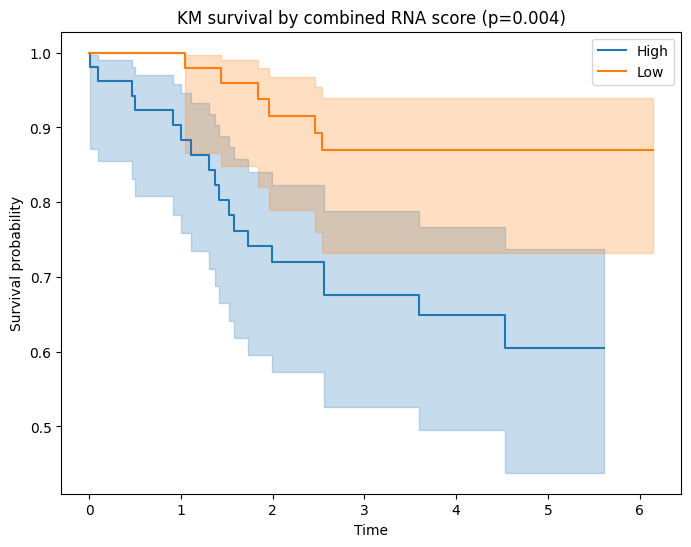

<lifelines.CoxPHFitter: fitted with 105 total observations, 81 right-censored observations>
             duration col = 'OS.from.sampling'
                event col = 'died'
      baseline estimation = breslow
   number of observations = 105
number of events observed = 24
   partial log-likelihood = -97.59
         time fit was run = 2025-09-04 11:16:09 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
FIRRE_NC      18.92  1.64e+08     10.31           -1.29           39.13                0.28            9.82e+16
LINC00158_NC  -4.21      0.01      5.66          -15.30            6.88                0.00              975.15
KCNJ2-AS1_NC   8.35   4236.11      8.29           -7.90           24.60                0.00            4.84e+10
MIR4458HG_NC   3.44     31.22     12.06          -20.20           27.08                0.00            5.79e+11
FLNB-AS1_NC  -15.35      0.00     13.06          -40.96           10.25                0.00            28256.81

              cmp to     z    p  -log2(p)
covariate                                
FIRRE_NC        0.00  1.83 0.07      3.91
LINC00158_NC    0.00 -0.74 0.46      1.13
KCNJ2-AS1_NC    0.00  1.01 0.31      1.67
MIR4458HG_NC    0.00  0.29 0.78      0.37
FLNB-AS1_NC     0.00 -1.18 0.24      2.06
---
Concordance = 0.74
Partial AIC = 205.18
log-likelihood ratio test = 16.56 on 5 df
-log2(p) of ll-ratio test = 7.53

In [6]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# --------------------------
# Step 1: Load data
# --------------------------
clinical = pd.read_csv("../../data/BCMO/clinical_info.csv")
expr = pd.read_csv("../../data/BCMO/activity_matrix_pvalfilt.csv", index_col=0)  # genes as rows

# Keep only the two RNAs
rna_of_interest = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "MIR4458HG_NC", "FLNB-AS1_NC"]
expr = expr.loc[rna_of_interest]  # subset rows

# Transpose to have samples as rows, genes as columns
expr = expr.T
expr.index.name = "Sample_ID"

# Merge with clinical data
data = clinical.merge(expr, on="Sample_ID")

# --------------------------
# Step 2: Create high/low groups per RNA
# --------------------------
for rna in rna_of_interest:
    data[rna + "_group"] = np.where(data[rna] > data[rna].median(), "High", "Low")

# Optional: create a combined score
data["combined_score"] = data[rna_of_interest].sum(axis=1)
data["combined_group"] = np.where(data["combined_score"] > data["combined_score"].median(), "High", "Low")

# --------------------------
# Step 3: Kaplan-Meier curves for combined group
# --------------------------
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8,6))

for label, group in data.groupby("combined_group"):
    kmf.fit(group["OS.from.sampling"], group["died"], label=label)
    kmf.plot_survival_function(ax=ax)

# Log-rank test
high = data[data["combined_group"]=="High"]
low = data[data["combined_group"]=="Low"]
results = logrank_test(high["OS.from.sampling"], low["OS.from.sampling"],
                       event_observed_A=high["died"], event_observed_B=low["died"])

plt.title(f"KM survival by combined RNA score (p={results.p_value:.3f})")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.show()

# --------------------------
# Step 4: Multivariate Cox regression
# --------------------------
cox_df = data[["OS.from.sampling", "died"] + rna_of_interest].copy()
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="OS.from.sampling", event_col="died")
cph.print_summary()